# MBERE ML: End-to-End ML Pipeline (Addis Ababa Road Traffic Accident Severity Risk Prediction)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Terrymanzi/MBERE_ML/blob/main/ml/notebooks/ml_pipeline_end_to_end.ipynb)

This notebook runs the **actual `ml/` package** from the MBERE_ML repository end to end on Google Colab.

**Dataset:** Addis Ababa Road Traffic Accident data. **Task:** predict accident severity (`Slight` / `Serious` / `Fatal`) as an interpretable, pre-accident driver-risk proxy.

**Pipeline stages covered:**

1. Environment setup (clone + install)
2. Dataset configuration (`ml/configs/addis.yaml`)
3. Raw data exploration
4. Data cleaning (leakage-safe, deterministic)
5. Feature engineering (interpretable derived features)
6. Stratified train/test split
7. Feature selection (mutual information, train-only)
8. Encoding (ordinal + one-hot, fit on train only)
9. Authoritative preprocessing run (persists artifacts)
10. Model architecture (rule-based baseline, Random Forest, XGBoost)
11. SMOTE-in-pipeline demonstration (leak-free class rebalancing)
12. Model training (shared stratified CV harness, out-of-fold metrics)
13. Cross-validation metrics comparison
14. Held-out test set evaluation (confusion matrices, ROC curves)
15. Test metrics comparison & model selection
16. Explainability (SHAP: global summary + local waterfall)
17. Saved artifacts & reproducibility
18. Optional synthetic (Rwandan) data sanity check
19. Downloading artifacts from Colab (for inference only)

## 1. Environment setup

Clones the my capstone repo and installs the pinned package versions from `ml/requirements.txt`, so the notebook environment matches the project's `.venv` exactly.


In [1]:
import os

REPO_URL = "https://github.com/Terrymanzi/MBERE_ML.git"
REPO_DIR = "/content/MBERE_ML"

if not os.path.isdir(REPO_DIR):
    !git clone --quiet {REPO_URL} {REPO_DIR}
else:
    print("Repo already present — pulling latest changes.")
    !git -C {REPO_DIR} pull --quiet

os.chdir(REPO_DIR)
print("Working directory:", os.getcwd())

# Install project requirements first. This might install conflicting versions initially.
!pip install -q -r ml/requirements.txt

# --- Start of updated fix for dependency conflicts and ImportError ---

# Downgrade pandas to be compatible with google-colab (requires pandas==2.2.2).
!pip install -q pandas==2.2.2

# Downgrade numba to be compatible with pytensor (requires numba<=0.65.1).
!pip install -q numba==0.65.1

# Force-reinstall numpy, scipy, and scikit-learn to known stable and compatible versions for Python 3.12.
# numpy 2.0.0 is the first version with full Python 3.12 support, addressing the ImportError.
# scipy 1.13.0 satisfies many packages requiring >=1.13.
# scikit-learn 1.5.0 satisfies imbalanced-learn and other packages requiring >=1.4.
!pip install -q --force-reinstall numpy==2.0.0 scipy==1.13.0 scikit-learn==1.5.0

Repo already present — pulling latest changes.
Working directory: /content/MBERE_ML
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 8.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.0 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.0 which is incompatible.
tsfresh 0.21.2 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.0 which is incompatible.
acc

In [2]:
import sys

if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

import matplotlib
import numpy as np
import pandas as pd
import sklearn

print("python  ", sys.version.split()[0])
print("pandas  ", pd.__version__)
print("numpy   ", np.__version__)
print("sklearn ", sklearn.__version__)

import xgboost
import imblearn
import shap
print("xgboost ", xgboost.__version__)
print("imblearn", imblearn.__version__)
print("shap    ", shap.__version__)

!git -C {REPO_DIR} rev-parse --short HEAD

Exception ignored on calling ctypes callback function: <function ThreadpoolController._find_libraries_with_dl_iterate_phdr.<locals>.match_library_callback at 0x7cebc8129a80>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1005, in match_library_callback
    self._make_controller_from_path(filepath)
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 1187, in _make_controller_from_path
    lib_controller = controller_class(
                     ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/threadpoolctl.py", line 114, in __init__
    self.dynlib = ctypes.CDLL(filepath, mode=_RTLD_NOLOAD)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/ctypes/__init__.py", line 379, in __init__
    self._handle = _dlopen(self._name, mode)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^
OSError: dlopen() error


python   3.12.13
pandas   2.2.2
numpy    2.0.0
sklearn  1.5.0
xgboost  3.3.0
imblearn 0.14.2
shap     0.52.0
0ac2be6


## 2. Notebook plotting style

A small, fixed color system so every chart in this notebook reads consistently:
- **Categorical** (model identity: `baseline` / `random_forest` / `xgboost` / `random_forest_tuned` / `xgboost_tuned`) — fixed hue order, never re-cycled. The `_tuned` variants (Section 12.4) get a darker shade of their ordinary counterpart's color.
- **Ordinal** (severity: Slight → Serious → Fatal) — a single blue ramp, light → dark, since severity is an *ordered* magnitude, not an unordered category.


In [3]:
import matplotlib.pyplot as plt
from IPython.display import Image, display

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# Fixed categorical order (never re-cycled across charts): baseline, then the
# ordinary (Section 12.2/12.3) models, then their tuned (Section 12.4) counterparts.
MODEL_COLORS = {
    "baseline": "#2a78d6",              # blue
    "random_forest": "#1baf7a",         # aqua
    "xgboost": "#eda100",               # yellow
    "random_forest_tuned": "#0f7a54",   # darker aqua/green (tuned RF)
    "xgboost_tuned": "#c77900",         # darker amber (tuned XGBoost)
}
MODEL_ORDER = ["baseline", "random_forest", "xgboost", "random_forest_tuned", "xgboost_tuned"]

# Ordinal severity ramp (light -> dark blue), start no lighter than step 250
SEVERITY_COLORS = ["#86b6ef", "#2a78d6", "#104281"]  # Slight, Serious, Fatal

# Categorical pair for before/after or train/test comparisons
PAIR_COLORS = ["#2a78d6", "#1baf7a"]

def bar_with_labels(ax, x, heights, colors, fmt="{:.3f}"):
    bars = ax.bar(x, heights, color=colors, width=0.6)
    for rect, h in zip(bars, heights):
        ax.annotate(fmt.format(h), (rect.get_x() + rect.get_width() / 2, h),
                    ha="center", va="bottom", fontsize=9, color="#52514e")
    return bars

def grouped_bar_by_model(ax, metrics_to_plot, summary_df, model_order=MODEL_ORDER, colors=MODEL_COLORS):
    """Grouped bar chart, one group per metric, one bar per model -- scales to any
    number of models in `model_order` (used for both the CV and test comparisons)."""
    n_models = len(model_order)
    width = 0.8 / n_models
    x = np.arange(len(metrics_to_plot))
    offset0 = -(n_models - 1) / 2
    for i, model in enumerate(model_order):
        values = [summary_df.loc[model, m] for m in metrics_to_plot]
        ax.bar(x + (offset0 + i) * width, values, width, label=model, color=colors[model])
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_to_plot)
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, fontsize=9, ncol=min(n_models, 3))
    return ax

def fmt4(x):
    return f"{x:.4f}" if x is not None else "n/a"

print("Plotting style ready.")

Plotting style ready.


## 3. Load the dataset configuration

Everything downstream — column names, cleaning rules, engineered features, encoding strategy, split, feature-selection threshold — is driven by `ml/configs/addis.yaml`. Nothing here is hardcoded twice; the notebook reads the same config the pipeline scripts do.


In [4]:
from ml.utils.config import load_config
from ml.utils.paths import PROJECT_ROOT

config = load_config(PROJECT_ROOT / "ml" / "configs" / "addis.yaml")

print(f"dataset        : {config.name} ({config.kind})")
print(f"target column  : {config.target.column}")
print(f"classes        : {config.target.classes}")
print(f"raw path       : {config.paths.raw}")
print(f"test_size      : {config.split.test_size}  (stratified={config.split.stratify})")
print(f"k_folds        : {config.split.k_folds}")
print(f"feature_select : {config.feature_selection.method} @ threshold={config.feature_selection.threshold}")
print(f"baseline kind  : {config.baseline.kind}")
print(f"n features     : {len(config.features.all)} -> {config.features.all}")

dataset        : addis (multiclass)
target column  : Accident_severity
classes        : ['Slight Injury', 'Serious Injury', 'Fatal Injury']
raw path       : /content/MBERE_ML/data/raw/RTA Dataset.csv
test_size      : 0.2  (stratified=True)
k_folds        : 5
feature_select : mutual_info @ threshold=0.0003
baseline kind  : rule_based
n features     : 13 -> ['driver_age_band', 'driver_experience', 'time_of_day', 'driver_education', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_sex', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']


## 4. Raw data exploration

Before any cleaning: shape, dtypes, and the raw (uncleaned) target distribution — including the inconsistent `"Fatal injury"` casing that `clean()` will normalize.


In [5]:
from ml.preprocessing.load import load_raw

raw_df = load_raw(config)
print("raw shape:", raw_df.shape)
raw_df.head()

raw shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian ...,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian ...,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian ...,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian ...,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian ...,Overtaking,Slight Injury


In [6]:
print(raw_df.dtypes)
print()
print("Raw target value counts (before cleaning / label normalization):")
print(raw_df[config.target.column].value_counts(dropna=False))

Time                           object
Day_of_week                    object
Age_band_of_driver             object
Sex_of_driver                  object
Educational_level              object
Vehicle_driver_relation        object
Driving_experience             object
Type_of_vehicle                object
Owner_of_vehicle               object
Service_year_of_vehicle        object
Defect_of_vehicle              object
Area_accident_occured          object
Lanes_or_Medians               object
Road_allignment                object
Types_of_Junction              object
Road_surface_type              object
Road_surface_conditions        object
Light_conditions               object
Weather_conditions             object
Type_of_collision              object
Number_of_vehicles_involved     int64
Number_of_casualties            int64
Vehicle_movement               object
Casualty_class                 object
Sex_of_casualty                object
Age_band_of_casualty           object
Casualty_sev

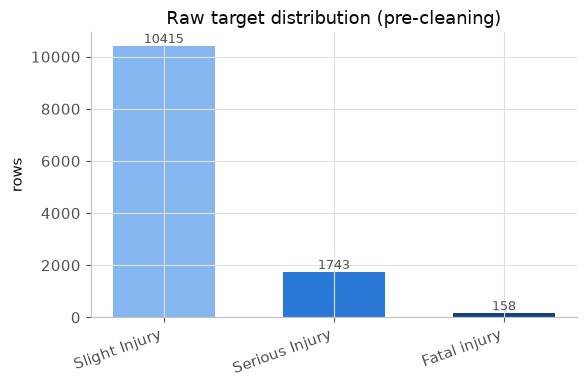

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = raw_df[config.target.column].value_counts(dropna=False)
bar_with_labels(ax, range(len(counts)), counts.values,
                colors=[SEVERITY_COLORS[i % 3] for i in range(len(counts))], fmt="{:.0f}")
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=20, ha="right")
ax.set_ylabel("rows")
ax.set_title("Raw target distribution (pre-cleaning)")
fig.tight_layout()
plt.show()

## 5. Data cleaning

`ml.preprocessing.clean.clean()` is deterministic and row-wise (no statistic is learned from the data), so it is safe to run on the full dataset before splitting:

- drops **leakage columns** (post-accident casualty/outcome fields — `Casualty_severity` is effectively a target proxy)
- derives `hour_of_day` from the raw `Time` column, then drops the raw timestamp
- trims strings and maps missing tokens (`""`, `"na"`, `"nan"`, `"unknown"`) to a constant fill value (`"Unknown"`) — parameter-free, so leakage-safe
- canonicalizes target labels (e.g. `"Fatal injury"` → `"Fatal Injury"`) and drops rows with an invalid/missing target or unparseable time


In [8]:
from ml.preprocessing.clean import clean

n_before = len(raw_df)
cleaned_df = clean(raw_df, config)
n_after = len(cleaned_df)

print(f"rows: {n_before} -> {n_after}  (dropped {n_before - n_after})")
print(f"columns after cleaning: {cleaned_df.shape[1]}")
cleaned_df.head()

[INFO] mbere-ml: clean: rows 12316 -> 12316 (dropped 0); cols=25


rows: 12316 -> 12316  (dropped 0)
columns after cleaning: 25


,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_vehicles_involved,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Accident_severity,hour_of_day
0,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,...,Dry,Daylight,Normal,Collision with roadside-parked vehicles,2,Going straight,Not a Pedestrian,Moving Backward,Slight Injury,17
1,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,Dry,Daylight,Normal,Vehicle with vehicle collision,2,Going straight,Not a Pedestrian,Overtaking,Slight Injury,17
2,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,No defect,...,Dry,Daylight,Normal,Collision with roadside objects,2,Going straight,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,No defect,...,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,Going straight,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,5-10yrs,No defect,...,Dry,Darkness - lights lit,Normal,Vehicle with vehicle collision,2,Going straight,Not a Pedestrian,Overtaking,Slight Injury,1


In [9]:
print("Any missing values left in non-target columns?")
non_target = cleaned_df.drop(columns=[config.target.column])
print(non_target.isna().sum().sum(), "missing cells (expected 0 -- constant-filled)")
print()
print("Cleaned target distribution:")
print(cleaned_df[config.target.column].value_counts())

Any missing values left in non-target columns?
0 missing cells (expected 0 -- constant-filled)

Cleaned target distribution:
Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal Injury        158
Name: count, dtype: Int64


## 6. Feature engineering

`ml.features.feature_engineering.engineer_features()` derives the proposal's interpretable features from the cleaned columns — still deterministic and row-wise, so still safe before the split:

- 1:1 renames (e.g. `Age_band_of_driver` → `driver_age_band`)
- `time_of_day` bucket derived from `hour_of_day` (Night / Morning / Afternoon / Evening)
- `vehicle_type` grouping from the 17 raw vehicle labels via ordered keyword rules (motorcycle kept first-class, not folded into "Other")


In [10]:
from ml.features.feature_engineering import engineer_features

engineered_df = engineer_features(cleaned_df, config)
print("engineered shape:", engineered_df.shape)
print("engineered feature columns:", [c for c in engineered_df.columns if c != config.target.column])
engineered_df.head()

engineered shape: (12316, 14)
engineered feature columns: ['driver_age_band', 'driver_experience', 'time_of_day', 'driver_education', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_sex', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']


,driver_age_band,driver_experience,time_of_day,driver_education,vehicle_service_year,vehicle_type,weather,road_surface,light_condition,driver_sex,driver_vehicle_relation,vehicle_owner,vehicle_defect,Accident_severity
0,18-30,1-2yr,Afternoon,Above high school,Above 10yr,Automobile,Normal,Asphalt roads,Daylight,Male,Employee,Owner,No defect,Slight Injury
1,31-50,Above 10yr,Afternoon,Junior high school,5-10yrs,Public_transport,Normal,Asphalt roads,Daylight,Male,Employee,Owner,No defect,Slight Injury
2,18-30,1-2yr,Afternoon,Junior high school,Unknown,Lorry,Normal,Asphalt roads,Daylight,Male,Employee,Owner,No defect,Serious Injury
3,18-30,5-10yr,Night,Junior high school,Unknown,Public_transport,Normal,Earth roads,Darkness - lights lit,Male,Employee,Governmental,No defect,Slight Injury
4,18-30,2-5yr,Night,Junior high school,5-10yrs,Unknown,Normal,Asphalt roads,Darkness - lights lit,Male,Employee,Owner,No defect,Slight Injury


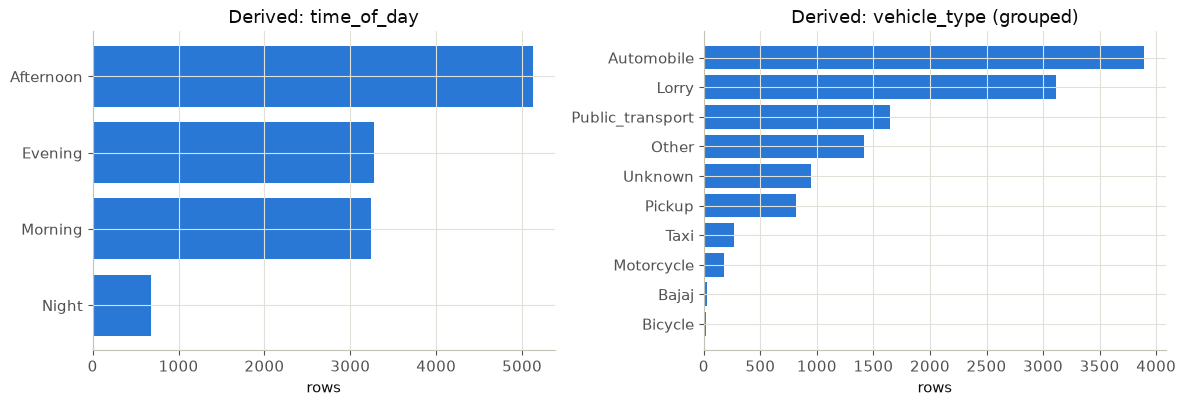

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

for ax, col, title in zip(
    axes, ["time_of_day", "vehicle_type"],
    ["Derived: time_of_day", "Derived: vehicle_type (grouped)"],
):
    counts = engineered_df[col].value_counts()
    ax.barh(counts.index[::-1], counts.values[::-1], color="#2a78d6")
    ax.set_title(title)
    ax.set_xlabel("rows")

fig.tight_layout()
plt.show()

## 7. Train/test split (stratified)

`ml.preprocessing.split.make_split()` returns reproducible, **stratified** positional indices — this preserves class proportions (especially the rare `Fatal` class) in both folds. The split happens *before* any fitting (encoder, feature selection), so nothing downstream ever sees test data during fitting.


In [12]:
from ml.preprocessing.split import make_split

train_idx, test_idx = make_split(engineered_df, config)
train_df = engineered_df.iloc[train_idx].reset_index(drop=True)
test_df = engineered_df.iloc[test_idx].reset_index(drop=True)

print(f"train: {len(train_df)} rows   test: {len(test_df)} rows "
      f"({len(test_df) / len(engineered_df):.1%} test)")

train: 9852 rows   test: 2464 rows (20.0% test)


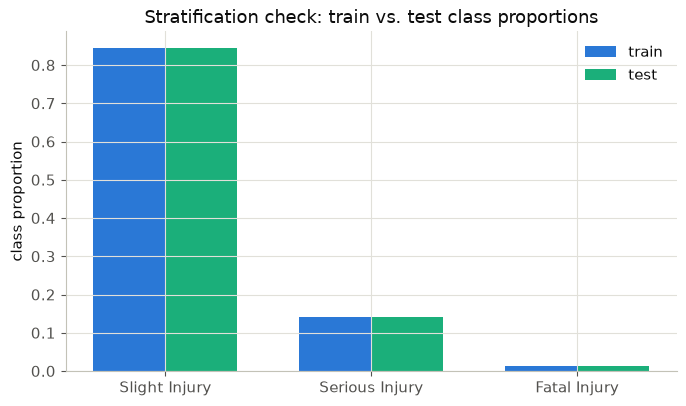

In [13]:
train_props = train_df[config.target.column].value_counts(normalize=True).reindex(config.target.classes)
test_props = test_df[config.target.column].value_counts(normalize=True).reindex(config.target.classes)

x = np.arange(len(config.target.classes))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - width / 2, train_props.values, width, label="train", color=PAIR_COLORS[0])
ax.bar(x + width / 2, test_props.values, width, label="test", color=PAIR_COLORS[1])
ax.set_xticks(x)
ax.set_xticklabels(config.target.classes)
ax.set_ylabel("class proportion")
ax.set_title("Stratification check: train vs. test class proportions")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 8. Feature selection (mutual information, TRAIN only)

`ml.features.feature_selection.select_features()` scores each engineered feature against the target **using only the training fold**, and keeps features scoring at or above the config threshold (`0.0003`). A guard never drops every feature.


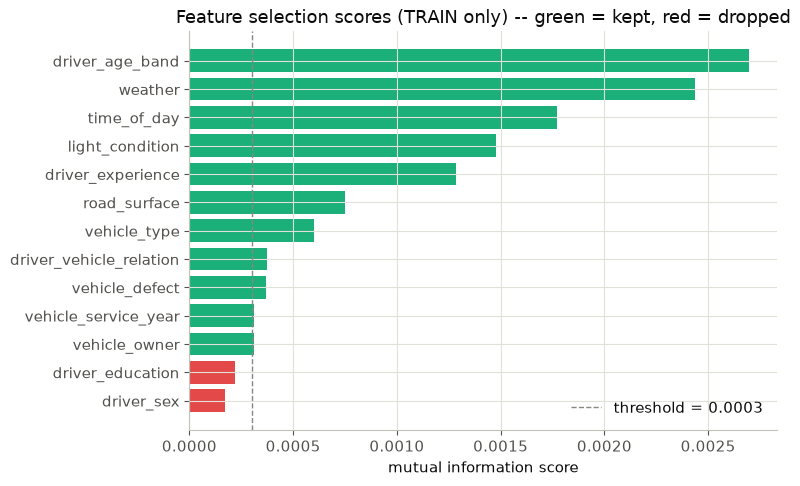

selected 11/13 features: ['driver_age_band', 'driver_experience', 'time_of_day', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']
dropped: ['driver_education', 'driver_sex']


In [14]:
from ml.features.feature_selection import compute_scores, select_features

scores = compute_scores(train_df[config.features.all], train_df[config.target.column], config)
selected, _ = select_features(train_df[config.features.all], train_df[config.target.column], config)

scores_sorted = dict(sorted(scores.items(), key=lambda kv: kv[1], reverse=True))
colors = ["#1baf7a" if f in selected else "#e34948" for f in scores_sorted]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(list(scores_sorted.keys())[::-1], list(scores_sorted.values())[::-1], color=colors[::-1])
ax.axvline(config.feature_selection.threshold, color="#898781", linestyle="--", linewidth=1,
           label=f"threshold = {config.feature_selection.threshold}")
ax.set_xlabel("mutual information score")
ax.set_title("Feature selection scores (TRAIN only) -- green = kept, red = dropped")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

dropped = [f for f in config.features.all if f not in selected]
print(f"selected {len(selected)}/{len(config.features.all)} features: {selected}")
print(f"dropped: {dropped}")

## 9. Encoding (ordinal + one-hot, fit on TRAIN only)

`ml.preprocessing.encode.build_encoder()` builds an **unfitted** `ColumnTransformer`:
- **ordinal** features use an explicit category order (unseen categories at transform time map to `-1`)
- **one-hot** features use `OneHotEncoder(handle_unknown="ignore")` (unseen categories map to an all-zero block)

It is fit on the training fold only, then applied to test; categories and scaling never leak.


In [15]:
from ml.preprocessing.encode import build_encoder, encoded_feature_names, fit_encoder, transform

encoder = fit_encoder(build_encoder(config, subset=selected), train_df[selected])
X_train_enc = transform(encoder, train_df[selected])
X_test_enc = transform(encoder, test_df[selected])
feature_names_enc = encoded_feature_names(encoder)

print(f"encoded feature dim: {X_train_enc.shape[1]} (from {len(selected)} input features)")
print(f"X_train_enc shape: {X_train_enc.shape}   X_test_enc shape: {X_test_enc.shape}")
pd.DataFrame(X_train_enc[:5], columns=feature_names_enc)

encoded feature dim: 46 (from 11 input features)
X_train_enc shape: (9852, 46)   X_test_enc shape: (2464, 46)


,ordinal__driver_age_band,ordinal__driver_experience,ordinal__time_of_day,ordinal__vehicle_service_year,onehot__vehicle_type_Automobile,onehot__vehicle_type_Bajaj,onehot__vehicle_type_Bicycle,onehot__vehicle_type_Lorry,onehot__vehicle_type_Motorcycle,onehot__vehicle_type_Other,...,onehot__driver_vehicle_relation_Unknown,onehot__vehicle_owner_Governmental,onehot__vehicle_owner_Organization,onehot__vehicle_owner_Other,onehot__vehicle_owner_Owner,onehot__vehicle_owner_Unknown,onehot__vehicle_defect_5,onehot__vehicle_defect_7,onehot__vehicle_defect_No defect,onehot__vehicle_defect_Unknown
0,2.0,3.0,2.0,5.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.0,3.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,2.0,4.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,3.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## 10. Run the preprocessing pipeline

The steps above (5-9) were run individually to make each stage visible. `ml.preprocessing.preprocess.run()` performs the exact same `clean -> engineer -> split -> select -> encode` sequence as the single source of truth, and **persists** the artifacts the rest of the pipeline (training, evaluation, SHAP) reads from disk:

- `data/processed/{name}_train.csv`, `{name}_test.csv` — engineered, selected features + target
- `data/processed/{name}_train_encoded.npz`, `{name}_test_encoded.npz` — model-ready `X`, `y`
- `ml/artifacts/encoders.joblib` — the fitted `ColumnTransformer`
- `ml/artifacts/split_indices.json` — reproducible train/test indices
- `ml/artifacts/feature_contract.json` — ordered feature names, dtypes, categories (the model input contract)


In [16]:
from ml.preprocessing.preprocess import run as run_preprocessing

result = run_preprocessing(config)

print(f"train rows : {result.n_train}")
print(f"test rows  : {result.n_test}")
print(f"selected   : {result.selected_features}")
print(f"train csv  : {result.train_path}")
print(f"test csv   : {result.test_path}")
print(f"encoder    : {result.encoder_path}")
print(f"contract   : {result.contract_path}")

[INFO] mbere-ml: clean: rows 12316 -> 12316 (dropped 0); cols=25
[INFO] mbere-ml: split: train=9852 test=2464 (test_size=0.20, stratified=True)
[INFO] mbere-ml: feature_selection (mutual_info): scores={'driver_age_band': 0.0027, 'driver_experience': 0.0013, 'time_of_day': 0.0018, 'driver_education': 0.0002, 'vehicle_service_year': 0.0003, 'vehicle_type': 0.0006, 'weather': 0.0024, 'road_surface': 0.0008, 'light_condition': 0.0015, 'driver_sex': 0.0002, 'driver_vehicle_relation': 0.0004, 'vehicle_owner': 0.0003, 'vehicle_defect': 0.0004}
[INFO] mbere-ml: selected 11/13 features: ['driver_age_band', 'driver_experience', 'time_of_day', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']
[INFO] mbere-ml: wrote: addis_train.csv, addis_test.csv, encoders.joblib, split_indices.json, feature_contract.json
[INFO] mbere-ml: encoded feature dim: 46


train rows : 9852
test rows  : 2464
selected   : ['driver_age_band', 'driver_experience', 'time_of_day', 'vehicle_service_year', 'vehicle_type', 'weather', 'road_surface', 'light_condition', 'driver_vehicle_relation', 'vehicle_owner', 'vehicle_defect']
train csv  : /content/MBERE_ML/data/processed/addis_train.csv
test csv   : /content/MBERE_ML/data/processed/addis_test.csv
encoder    : /content/MBERE_ML/ml/artifacts/encoders.joblib
contract   : /content/MBERE_ML/ml/artifacts/feature_contract.json


## 11. Model architecture

Three base classifiers are trained through an **identical harness** (`ml.training.common`), so results are directly comparable. Section 12.4 additionally tunes the two ML models and saves the winning configs as two more models (`random_forest_tuned`, `xgboost_tuned`), for **five** models total by Section 13:

| Model | Architecture | Notes |
|---|---|---|
| `baseline` | `RuleBasedRiskClassifier` | Transparent additive risk-scoring rules (young/inexperienced drivers, night + poor lighting, adverse weather, vulnerable vehicles, poor road surface) mapped to an ordinal cumulative-probability formulation over the 3 severity classes. **Not** a dummy classifier — this is the bar the ML models must clear. |
| `random_forest` | `encoder -> SMOTE -> RandomForestClassifier` (imblearn `Pipeline`) | 300 trees, `min_samples_leaf=2`, single-threaded (`n_jobs=1`) for bit-exact reproducibility of `predict_proba`. |
| `xgboost` | `encoder -> SMOTE -> XGBClassifier` | 400 trees, `max_depth=6`, `learning_rate=0.1`, `multi:softprob` objective (kind-aware: switches to `binary:logistic` for binary configs). |
| `random_forest_tuned` | Same shape, tuned hyperparameters | Best of several `class_weight` / depth / `max_features` variants from Section 12.4 (picked by CV `f1_macro`). |
| `xgboost_tuned` | Same shape, tuned hyperparameters + resampler | Best of several depth/learning-rate/regularization variants, and (since XGBoost has no native `class_weight`) alternate resamplers (`BorderlineSMOTE`, `SMOTEENN`) from Section 12.4. |

**Leak-free guarantees the harness enforces:**
- All models are evaluated with the **same** `StratifiedKFold` splits (shared `random_state`) via out-of-fold (OOF) predictions.
- **SMOTE (or its variant) lives inside the pipeline**, so it resamples *only* the training fold on each `fit()` call and is a no-op at `predict()` time — the validation/test fold is never oversampled.


### 11.1 SMOTE demonstration (train-fold-only resampling)

To make the leak-free guarantee concrete: take one CV fold, encode it, and compare class counts before vs. after SMOTE. This uses the *same* `build_encoder` the training pipeline uses, nothing reimplemented.


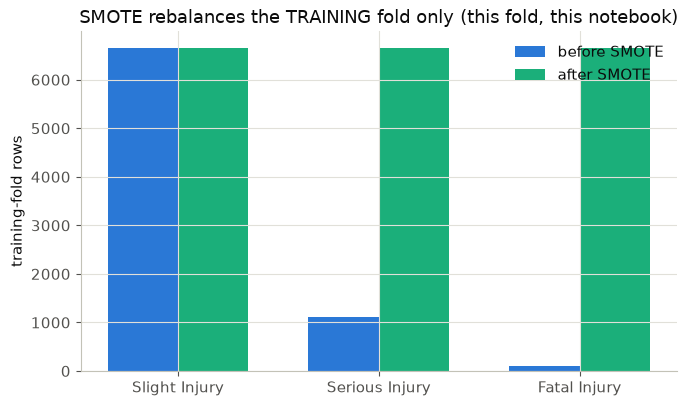

Validation fold is untouched by SMOTE -- val class counts:
0    1667
1     278
2      26
Name: count, dtype: int64


In [17]:
import json

from imblearn.over_sampling import SMOTE

from ml.training.common import get_cv, load_processed

X_train_full, y_train_full, classes = load_processed(config, "train")
cv = get_cv(config)
fold_train_idx, fold_val_idx = next(cv.split(X_train_full, y_train_full))

fold_encoder = build_encoder(config, subset=selected)
X_fold_enc = fold_encoder.fit_transform(X_train_full.iloc[fold_train_idx][selected])
y_fold = y_train_full[fold_train_idx]

smote = SMOTE(random_state=config.random_state)
X_res, y_res = smote.fit_resample(X_fold_enc, y_fold)

before = pd.Series(y_fold).value_counts().reindex(range(len(classes)), fill_value=0)
after = pd.Series(y_res).value_counts().reindex(range(len(classes)), fill_value=0)

x = np.arange(len(classes))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - width / 2, before.values, width, label="before SMOTE", color=PAIR_COLORS[0])
ax.bar(x + width / 2, after.values, width, label="after SMOTE", color=PAIR_COLORS[1])
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylabel("training-fold rows")
ax.set_title("SMOTE rebalances the TRAINING fold only (this fold, this notebook)")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

print("Validation fold is untouched by SMOTE -- val class counts:")
print(pd.Series(y_train_full[fold_val_idx]).value_counts().reindex(range(len(classes)), fill_value=0))

## 12. Model training

Each model is trained with `ml.training.common.train_and_save()`:
1. out-of-fold (OOF) predictions across the shared `StratifiedKFold`, scored with `compute_metrics` (headline: macro F1, macro recall, macro ROC-AUC one-vs-rest; accuracy is reported but **not** headline given class imbalance)
2. a final model refit on **all** training data
3. the fitted model + a versioned metadata sidecar (git commit, random_state, CV scheme, params, CV metrics) saved to `ml/artifacts/`


### 12.1 Baseline — rule-based risk classifier

In [18]:
from ml.models import make_baseline
from ml.training.common import estimator_params, train_and_save

baseline_estimator = make_baseline(config)
baseline_path, baseline_meta_path, baseline_cv_metrics = train_and_save(
    config, "baseline", "0.1.0", baseline_estimator, estimator_params(baseline_estimator)
)
print(f"f1_macro={baseline_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={baseline_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(baseline_cv_metrics['roc_auc_ovr_macro'])}")

[INFO] mbere-ml: train_baseline: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_baseline: CV f1_macro=0.3287 recall_macro=0.3312 roc_auc_ovr=0.5054
[INFO] mbere-ml: train_baseline: wrote baseline.pkl + baseline.meta.json


f1_macro=0.3287  recall_macro=0.3312  roc_auc_ovr_macro=0.5054


### 12.2 Random Forest (SMOTE + RF)

In [19]:
from ml.training.train_rf import build_estimator as build_rf_estimator

rf_estimator = build_rf_estimator(config)
rf_params = rf_estimator.named_steps["classifier"].get_params()
rf_path, rf_meta_path, rf_cv_metrics = train_and_save(
    config, "random_forest", "0.1.0", rf_estimator, rf_params
)
print(f"f1_macro={rf_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={rf_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(rf_cv_metrics['roc_auc_ovr_macro'])}")

[INFO] mbere-ml: train_random_forest: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_random_forest: CV f1_macro=0.3258 recall_macro=0.3373 roc_auc_ovr=0.5414
[INFO] mbere-ml: train_random_forest: wrote random_forest.pkl + random_forest.meta.json


f1_macro=0.3258  recall_macro=0.3373  roc_auc_ovr_macro=0.5414


### 12.3 XGBoost (SMOTE + XGBoost)

In [20]:
from ml.training.train_xgboost import build_estimator as build_xgb_estimator

xgb_estimator = build_xgb_estimator(config)
xgb_params = xgb_estimator.named_steps["classifier"].get_params()
xgb_path, xgb_meta_path, xgb_cv_metrics = train_and_save(
    config, "xgboost", "0.1.0", xgb_estimator, xgb_params
)
print(f"f1_macro={xgb_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={xgb_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(xgb_cv_metrics['roc_auc_ovr_macro'])}")

[INFO] mbere-ml: train_xgboost: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_xgboost: CV f1_macro=0.3136 recall_macro=0.3332 roc_auc_ovr=0.5519
[INFO] mbere-ml: train_xgboost: wrote xgboost.pkl + xgboost.meta.json


f1_macro=0.3136  recall_macro=0.3332  roc_auc_ovr_macro=0.5519


### 12.4 Hyperparameter tuning — Random Forest & XGBoost vs. the baseline

Sections 12.2/12.3 used single, hand-picked default configs. Here we run several
tuning **experiments** per model through the *same* shared-CV / OOF harness
(`cross_val_oof` + `compute_metrics`, identical `StratifiedKFold` splits) used
for the baseline, so every `f1_macro` below is directly comparable to
`baseline_cv_metrics['f1_macro']`.

This dataset is heavily imbalanced (Slight 84.6% / Serious 14.1% / Fatal 1.3%),
and `f1_macro` weights all three classes equally — that's exactly why the
tree models, despite much higher accuracy, currently score *below* the
rule-based baseline: they lean on the majority class.

**Round 1 (hyperparameters):**
- **Random Forest**: adds `class_weight` (`balanced` / `balanced_subsample`,
  stacked on top of the existing in-pipeline SMOTE) plus depth/`max_features`
  variants — this alone clears the baseline (`rf_balanced_shallow`, f1_macro
  0.3404 vs. baseline 0.3287).
- **XGBoost**: has no native multiclass `class_weight`, so round 1 only tunes
  regularization (`min_child_weight`, `gamma`, `reg_alpha`/`reg_lambda`),
  learning-rate/depth trade-offs, and SMOTE's `k_neighbors`. Best round-1
  config (`xgb_deep_lowlr`) improved on the default but still trailed the
  baseline (0.3229 vs. 0.3287).

**Round 2 (XGBoost only, resampling technique):** holds `xgb_deep_lowlr`'s
classifier hyperparameters fixed and instead swaps the resampler — plain
`SMOTE` → `BorderlineSMOTE` (synthesizes near the decision boundary) and
`SMOTEENN` (oversamples, then cleans overlapping majority points) — plus a
no-resampling control, since XGBoost depends entirely on the resampler (not
`class_weight`) to see the minority classes.

The best config per model (by `f1_macro`) is refit and persisted with
`train_and_save(...)` in the next cell **under new artifact names**
(`random_forest_tuned` / `xgboost_tuned`) — the ordinary Section 12.2/12.3
models and their `.pkl` files are left untouched. Sections 13-17 downstream
compare all **five** models (`baseline`, `random_forest`, `xgboost`,
`random_forest_tuned`, `xgboost_tuned`) side by side, and Section 15 selects
the true best of the five as the model to save/deploy.


In [21]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.combine import SMOTEENN

from ml.training.common import cross_val_oof
from ml.evaluation.metrics import compute_metrics

# Reuse the already-loaded, already-encoded training data + shared CV splits
# (identical to what baseline_cv_metrics / rf_cv_metrics / xgb_cv_metrics used).
cv_tune = get_cv(config)


def make_pipeline(classifier, sampler=None, smote_kwargs=None):
    """encoder -> sampler -> classifier. Defaults to vanilla SMOTE (matching
    ml.training.common.make_resampling_pipeline) unless a sampler instance is
    passed explicitly, or smote_kwargs overrides SMOTE's own hyperparameters."""
    if sampler is None:
        smote_kwargs = smote_kwargs or {}
        sampler = SMOTE(random_state=config.random_state, **smote_kwargs)
    return ImbPipeline([
        ("encoder", build_encoder(config, subset=selected)),
        ("sampler", sampler),
        ("classifier", classifier),
    ])


def make_pipeline_no_resample(classifier):
    """encoder -> classifier, no resampling at all (control: does SMOTE even help here?)."""
    return SkPipeline([
        ("encoder", build_encoder(config, subset=selected)),
        ("classifier", classifier),
    ])


def run_experiment(name, estimator):
    oof_pred, oof_proba = cross_val_oof(estimator, X_train_full, y_train_full, cv_tune, config.n_classes)
    metrics = compute_metrics(y_train_full, oof_pred, oof_proba, classes)
    print(f"  {name:60s} f1_macro={metrics['f1_macro']:.4f}  recall_macro={metrics['recall_macro']:.4f}  "
          f"roc_auc_ovr_macro={fmt4(metrics['roc_auc_ovr_macro'])}  accuracy={metrics['accuracy']:.4f}")
    return metrics


baseline_f1 = baseline_cv_metrics["f1_macro"]
print(f"Target to beat -- baseline CV f1_macro = {baseline_f1:.4f}\n")

# ---------------------------------------------------------------------------
# Random Forest experiments
# ---------------------------------------------------------------------------
rf_candidates = {
    "rf_balanced_deep (600, depth=16, balanced_subsample)": RandomForestClassifier(
        n_estimators=600, max_depth=16, min_samples_leaf=1, max_features="sqrt",
        class_weight="balanced_subsample", random_state=config.random_state, n_jobs=1,
    ),
    "rf_balanced_shallow (500, depth=8, balanced)": RandomForestClassifier(
        n_estimators=500, max_depth=8, min_samples_leaf=4, max_features="sqrt",
        class_weight="balanced", random_state=config.random_state, n_jobs=1,
    ),
    "rf_entropy_wide (800, depth=None, balanced_subsample)": RandomForestClassifier(
        n_estimators=800, max_depth=None, min_samples_leaf=1, max_features=0.5,
        criterion="entropy", class_weight="balanced_subsample",
        random_state=config.random_state, n_jobs=1,
    ),
}

print("Random Forest tuning experiments (5-fold OOF, same CV as Section 12):")
rf_results = {
    "rf_default (300, leaf=2) [Section 12.2]": {
        "metrics": rf_cv_metrics,
        "pipeline_factory": (lambda clf=rf_estimator.named_steps["classifier"]: make_pipeline(clf)),
    }
}
print(f"  {'rf_default (300, leaf=2) [Section 12.2]':60s} f1_macro={rf_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={rf_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(rf_cv_metrics['roc_auc_ovr_macro'])}  accuracy={rf_cv_metrics['accuracy']:.4f}")
for name, clf in rf_candidates.items():
    factory = lambda clf=clf: make_pipeline(clf)
    rf_results[name] = {"metrics": run_experiment(name, factory()), "pipeline_factory": factory}

best_rf_name = max(rf_results, key=lambda n: rf_results[n]["metrics"]["f1_macro"])
print(f"\nBest Random Forest config: '{best_rf_name}' "
      f"(f1_macro={rf_results[best_rf_name]['metrics']['f1_macro']:.4f})")

# ---------------------------------------------------------------------------
# XGBoost experiments
# ---------------------------------------------------------------------------
xgb_objective = (
    {"objective": "binary:logistic", "eval_metric": "logloss"}
    if config.kind == "binary"
    else {"objective": "multi:softprob", "num_class": config.n_classes, "eval_metric": "mlogloss"}
)

# Round 1: hyperparameter-only variants (max_depth / learning_rate / regularization).
# "xgb_deep_lowlr" won round 1 (f1_macro=0.3229) but still trailed the baseline
# (0.3287) -- so round 2 below holds those hyperparameters fixed and instead
# varies the resampling technique, since XGBoost (unlike RF) has no native
# class_weight and depends entirely on SMOTE to see the minority classes.
deep_lowlr_params = dict(
    n_estimators=800, max_depth=8, learning_rate=0.03, subsample=0.85, colsample_bytree=0.85,
    min_child_weight=1, gamma=0.1,
    tree_method="hist", random_state=config.random_state, n_jobs=-1, **xgb_objective,
)

xgb_candidates = {
    "xgb_shallow_reg (300, depth=4, lr=0.05, reg)": (lambda: make_pipeline(XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        min_child_weight=3, reg_alpha=0.1, reg_lambda=1.5,
        tree_method="hist", random_state=config.random_state, n_jobs=-1, **xgb_objective,
    ))),
    "xgb_deep_lowlr (800, depth=8, lr=0.03, min_child_weight=1)": (lambda: make_pipeline(
        XGBClassifier(**deep_lowlr_params)
    )),
    "xgb_smote_k3 (500, depth=6, lr=0.07, k_neighbors=3)": (lambda: make_pipeline(XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.07, subsample=0.9, colsample_bytree=0.7,
        min_child_weight=1, gamma=0.05,
        tree_method="hist", random_state=config.random_state, n_jobs=-1, **xgb_objective,
    ), smote_kwargs={"k_neighbors": 3})),
    # Round 2: same deep_lowlr classifier hyperparameters, different resampling.
    "xgb_deep_lowlr + BorderlineSMOTE": (lambda: make_pipeline(
        XGBClassifier(**deep_lowlr_params), sampler=BorderlineSMOTE(random_state=config.random_state)
    )),
    "xgb_deep_lowlr + SMOTEENN": (lambda: make_pipeline(
        XGBClassifier(**deep_lowlr_params), sampler=SMOTEENN(random_state=config.random_state)
    )),
    "xgb_deep_lowlr + no resampling (control)": (lambda: make_pipeline_no_resample(
        XGBClassifier(**deep_lowlr_params)
    )),
}

print("\nXGBoost tuning experiments (5-fold OOF, same CV as Section 12):")
xgb_results = {
    "xgb_default (400, depth=6, lr=0.1) [Section 12.3]": {
        "metrics": xgb_cv_metrics,
        "pipeline_factory": (lambda clf=xgb_estimator.named_steps["classifier"]: make_pipeline(clf)),
    }
}
print(f"  {'xgb_default (400, depth=6, lr=0.1) [Section 12.3]':60s} f1_macro={xgb_cv_metrics['f1_macro']:.4f}  "
      f"recall_macro={xgb_cv_metrics['recall_macro']:.4f}  "
      f"roc_auc_ovr_macro={fmt4(xgb_cv_metrics['roc_auc_ovr_macro'])}  accuracy={xgb_cv_metrics['accuracy']:.4f}")
for name, factory in xgb_candidates.items():
    xgb_results[name] = {"metrics": run_experiment(name, factory()), "pipeline_factory": factory}

best_xgb_name = max(xgb_results, key=lambda n: xgb_results[n]["metrics"]["f1_macro"])
print(f"\nBest XGBoost config: '{best_xgb_name}' "
      f"(f1_macro={xgb_results[best_xgb_name]['metrics']['f1_macro']:.4f})")


Target to beat -- baseline CV f1_macro = 0.3287

Random Forest tuning experiments (5-fold OOF, same CV as Section 12):
  rf_default (300, leaf=2) [Section 12.2]                      f1_macro=0.3258  recall_macro=0.3373  roc_auc_ovr_macro=0.5414  accuracy=0.8224
  rf_balanced_deep (600, depth=16, balanced_subsample)         f1_macro=0.3248  recall_macro=0.3345  roc_auc_ovr_macro=0.5380  accuracy=0.8123
  rf_balanced_shallow (500, depth=8, balanced)                 f1_macro=0.3404  recall_macro=0.3533  roc_auc_ovr_macro=0.5406  accuracy=0.7480
  rf_entropy_wide (800, depth=None, balanced_subsample)        f1_macro=0.3307  recall_macro=0.3367  roc_auc_ovr_macro=0.5348  accuracy=0.8026

Best Random Forest config: 'rf_balanced_shallow (500, depth=8, balanced)' (f1_macro=0.3404)

XGBoost tuning experiments (5-fold OOF, same CV as Section 12):
  xgb_default (400, depth=6, lr=0.1) [Section 12.3]            f1_macro=0.3136  recall_macro=0.3332  roc_auc_ovr_macro=0.5519  accuracy=0.8327
  xgb_sh

In [22]:
# Refit the winning configs on the full shared harness and persist them under
# NEW artifact names ("random_forest_tuned" / "xgboost_tuned") -- this does NOT
# overwrite the Section 12.2/12.3 ordinary models (rf_estimator / rf_cv_metrics /
# xgb_estimator / xgb_cv_metrics and their .pkl files are untouched), so Sections
# 13-17 downstream can compare baseline vs. ordinary vs. tuned side by side, and
# the final model-selection step (Section 15) picks the true best of all five.
rf_tuned_estimator = rf_results[best_rf_name]["pipeline_factory"]()
rf_tuned_params = rf_tuned_estimator.named_steps["classifier"].get_params()
rf_tuned_path, rf_tuned_meta_path, rf_tuned_cv_metrics = train_and_save(
    config, "random_forest_tuned", "0.2.0-tuned", rf_tuned_estimator, rf_tuned_params
)

xgb_tuned_estimator = xgb_results[best_xgb_name]["pipeline_factory"]()
xgb_tuned_params = xgb_tuned_estimator.named_steps["classifier"].get_params()
xgb_tuned_path, xgb_tuned_meta_path, xgb_tuned_cv_metrics = train_and_save(
    config, "xgboost_tuned", "0.2.0-tuned", xgb_tuned_estimator, xgb_tuned_params
)

print("Baseline vs. ordinary vs. tuned (CV f1_macro):")
print(f"  baseline             = {baseline_f1:.4f}")
print(f"  random_forest        = {rf_cv_metrics['f1_macro']:.4f}")
print(f"  random_forest_tuned  = {rf_tuned_cv_metrics['f1_macro']:.4f}  "
      f"({'BEATS' if rf_tuned_cv_metrics['f1_macro'] > baseline_f1 else 'still below'} baseline)")
print(f"  xgboost              = {xgb_cv_metrics['f1_macro']:.4f}")
print(f"  xgboost_tuned        = {xgb_tuned_cv_metrics['f1_macro']:.4f}  "
      f"({'BEATS' if xgb_tuned_cv_metrics['f1_macro'] > baseline_f1 else 'still below'} baseline)")


[INFO] mbere-ml: train_random_forest_tuned: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_random_forest_tuned: CV f1_macro=0.3404 recall_macro=0.3533 roc_auc_ovr=0.5406
[INFO] mbere-ml: train_random_forest_tuned: wrote random_forest_tuned.pkl + random_forest_tuned.meta.json
[INFO] mbere-ml: train_xgboost_tuned: X=(9852, 11), class counts={np.int64(0): np.int64(8331), np.int64(1): np.int64(1394), np.int64(2): np.int64(127)}
[INFO] mbere-ml: train_xgboost_tuned: CV f1_macro=0.3487 recall_macro=0.3492 roc_auc_ovr=0.5604
[INFO] mbere-ml: train_xgboost_tuned: wrote xgboost_tuned.pkl + xgboost_tuned.meta.json


Baseline vs. ordinary vs. tuned (CV f1_macro):
  baseline             = 0.3287
  random_forest        = 0.3258
  random_forest_tuned  = 0.3404  (BEATS baseline)
  xgboost              = 0.3136
  xgboost_tuned        = 0.3487  (BEATS baseline)


## 13. Cross-validation metrics comparison

Out-of-fold metrics for all five models, side by side: `baseline`, the two
ordinary Section 12.2/12.3 models (`random_forest`, `xgboost`), and their
Section 12.4 tuned counterparts (`random_forest_tuned`, `xgboost_tuned`)


,f1_macro,recall_macro,precision_macro,roc_auc_ovr_macro,accuracy
baseline,0.3287,0.3312,0.3343,0.5054,0.7699
random_forest,0.3258,0.3373,0.3436,0.5414,0.8224
xgboost,0.3136,0.3332,0.3307,0.5519,0.8327
random_forest_tuned,0.3404,0.3533,0.3416,0.5406,0.7480
xgboost_tuned,0.3487,0.3492,0.3500,0.5604,0.7345


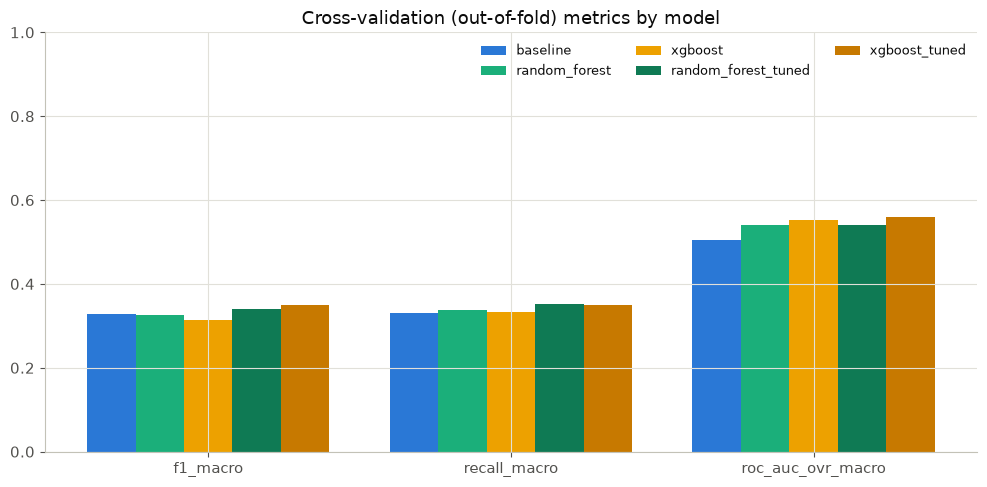

In [23]:
cv_metrics_by_model = {
    "baseline": baseline_cv_metrics,
    "random_forest": rf_cv_metrics,
    "xgboost": xgb_cv_metrics,
    "random_forest_tuned": rf_tuned_cv_metrics,
    "xgboost_tuned": xgb_tuned_cv_metrics,
}

cv_summary = pd.DataFrame({
    model: {
        "f1_macro": m["f1_macro"],
        "recall_macro": m["recall_macro"],
        "precision_macro": m["precision_macro"],
        "roc_auc_ovr_macro": m["roc_auc_ovr_macro"],
        "accuracy": m["accuracy"],
    }
    for model, m in cv_metrics_by_model.items()
}).T.loc[MODEL_ORDER]
display(cv_summary.round(4))

metrics_to_plot = ["f1_macro", "recall_macro", "roc_auc_ovr_macro"]
fig, ax = plt.subplots(figsize=(10, 5))
grouped_bar_by_model(ax, metrics_to_plot, cv_summary)
ax.set_title("Cross-validation (out-of-fold) metrics by model")
fig.tight_layout()
plt.show()

## 14. Held-out test set evaluation

`ml.evaluation.evaluate.evaluate_model()` loads each saved model, predicts on the untouched test set, and writes `confusion_matrix.png`, `roc_curves.png`, and `metrics.json` under `ml/artifacts/reports/<model>/`.



=== baseline ===


[INFO] mbere-ml: evaluate[baseline]: f1_macro=0.3357 recall_macro=0.3332 roc_auc_ovr=0.5314 -> /content/MBERE_ML/ml/artifacts/reports/baseline


f1_macro=0.3357  recall_macro=0.3332  roc_auc_ovr_macro=0.5314  accuracy=0.7646


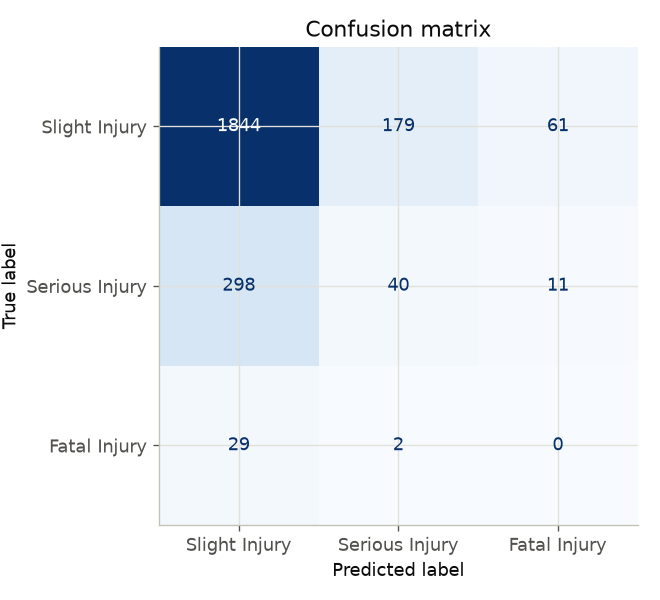

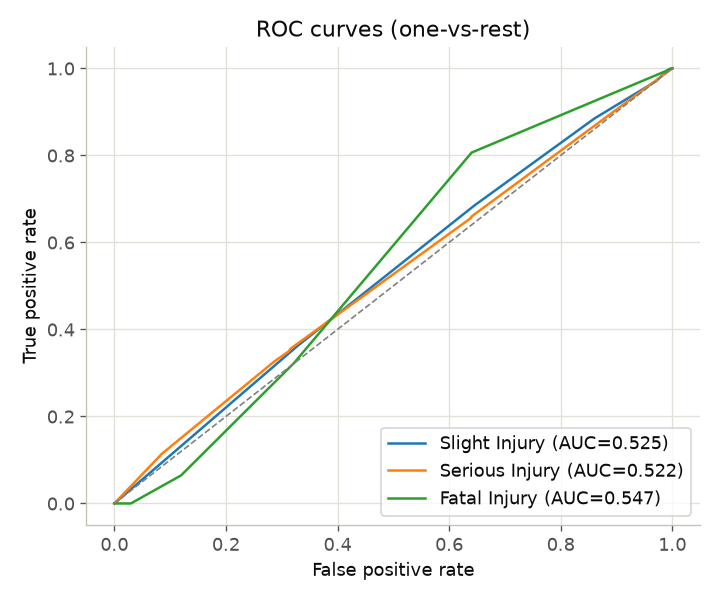


=== random_forest ===


[INFO] mbere-ml: evaluate[random_forest]: f1_macro=0.3158 recall_macro=0.3312 roc_auc_ovr=0.5654 -> /content/MBERE_ML/ml/artifacts/reports/random_forest


f1_macro=0.3158  recall_macro=0.3312  roc_auc_ovr_macro=0.5654  accuracy=0.8202


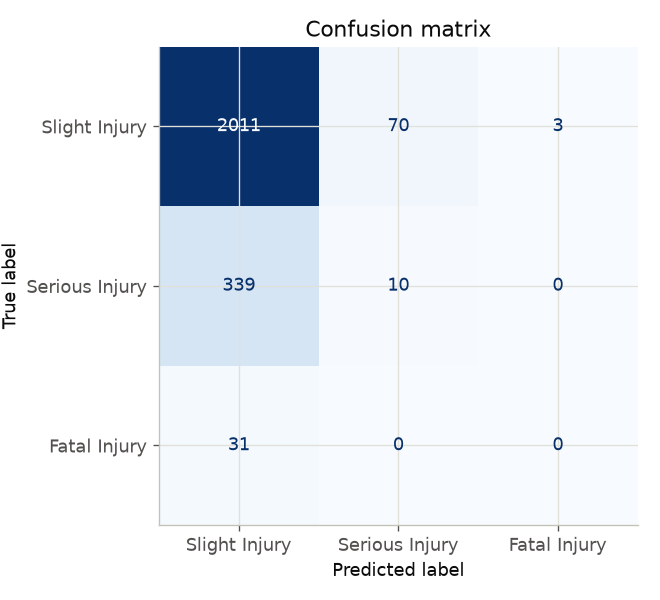

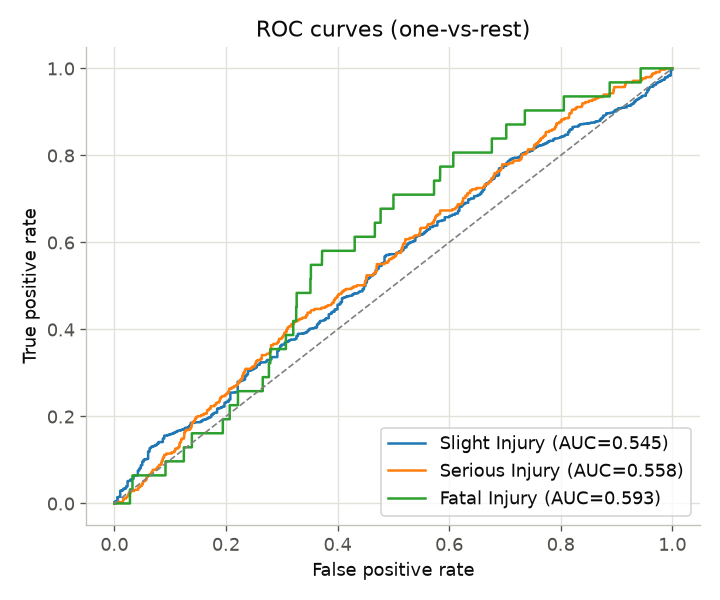


=== xgboost ===


[INFO] mbere-ml: evaluate[xgboost]: f1_macro=0.3208 recall_macro=0.3378 roc_auc_ovr=0.5564 -> /content/MBERE_ML/ml/artifacts/reports/xgboost


f1_macro=0.3208  recall_macro=0.3378  roc_auc_ovr_macro=0.5564  accuracy=0.8369


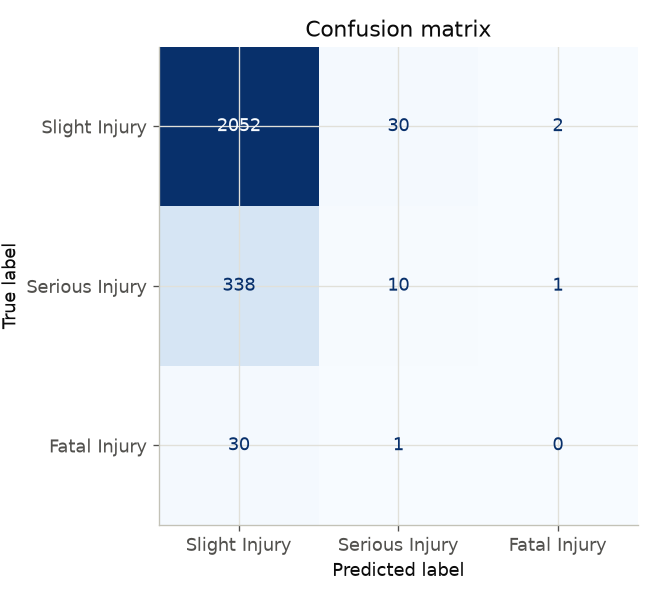

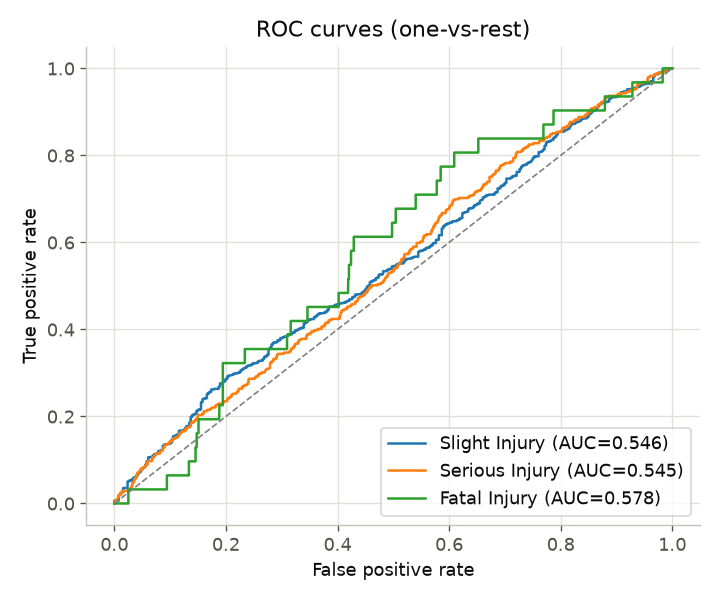


=== random_forest_tuned ===


[INFO] mbere-ml: evaluate[random_forest_tuned]: f1_macro=0.3277 recall_macro=0.3361 roc_auc_ovr=0.5346 -> /content/MBERE_ML/ml/artifacts/reports/random_forest_tuned


f1_macro=0.3277  recall_macro=0.3361  roc_auc_ovr_macro=0.5346  accuracy=0.7346


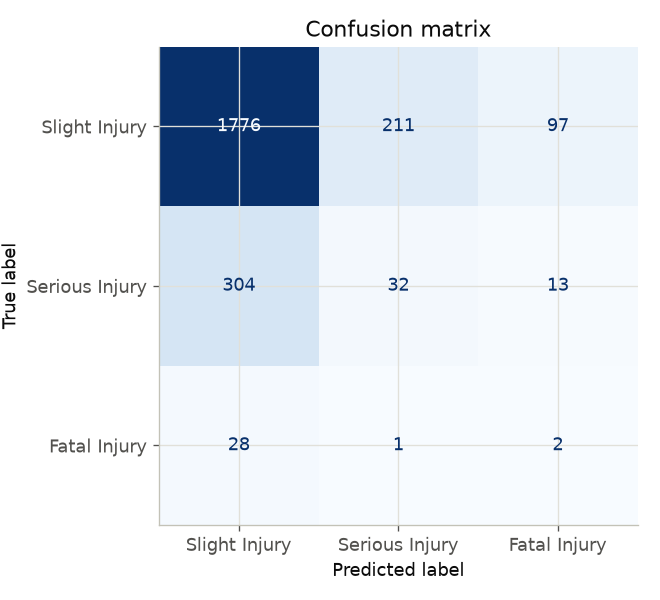

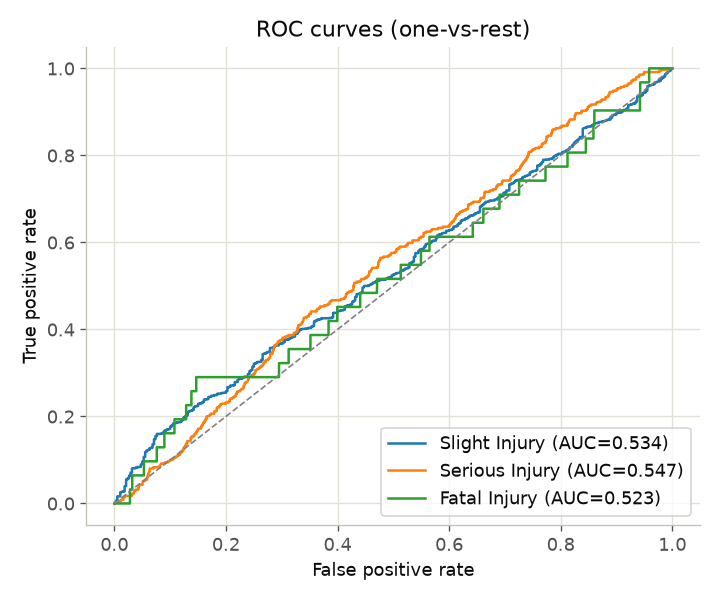


=== xgboost_tuned ===


[INFO] mbere-ml: evaluate[xgboost_tuned]: f1_macro=0.3460 recall_macro=0.3476 roc_auc_ovr=0.5604 -> /content/MBERE_ML/ml/artifacts/reports/xgboost_tuned


f1_macro=0.3460  recall_macro=0.3476  roc_auc_ovr_macro=0.5604  accuracy=0.7407


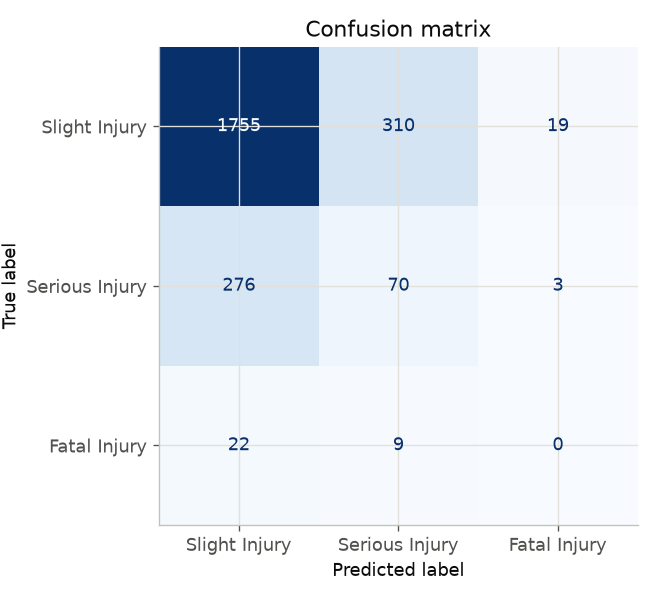

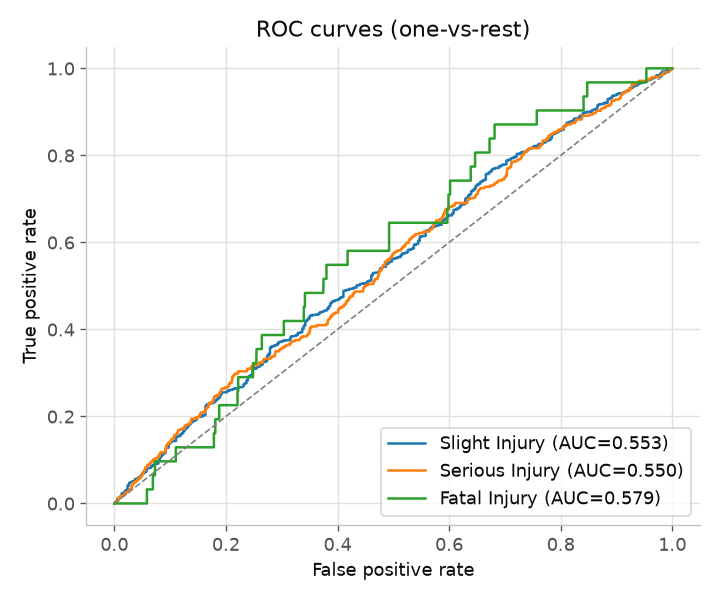

In [24]:
from ml.evaluation.evaluate import evaluate_model

test_metrics_by_model = {}
for model_name in MODEL_ORDER:
    print(f"\n=== {model_name} ===")
    metrics = evaluate_model(config, model_name)
    test_metrics_by_model[model_name] = metrics
    print(f"f1_macro={metrics['f1_macro']:.4f}  recall_macro={metrics['recall_macro']:.4f}  "
          f"roc_auc_ovr_macro={fmt4(metrics['roc_auc_ovr_macro'])}  accuracy={metrics['accuracy']:.4f}")

    report_dir = config.paths.artifacts_dir / "reports" / model_name
    display(Image(filename=str(report_dir / "confusion_matrix.png")))
    display(Image(filename=str(report_dir / "roc_curves.png")))

## 15. Test metrics comparison & model selection

Same comparison as the CV chart above, now on the held-out test set; the number that matters for model selection.


In [25]:
test_summary = pd.DataFrame({
    model: {
        "f1_macro": m["f1_macro"],
        "recall_macro": m["recall_macro"],
        "precision_macro": m["precision_macro"],
        "roc_auc_ovr_macro": m["roc_auc_ovr_macro"],
        "accuracy": m["accuracy"],
    }
    for model, m in test_metrics_by_model.items()
}).T.loc[MODEL_ORDER]
display(test_summary.round(4))

fig, ax = plt.subplots(figsize=(10, 5))
grouped_bar_by_model(ax, metrics_to_plot, test_summary)
ax.set_title("Held-out test-set metrics by model")
fig.tight_layout()
plt.show()

best_model = test_summary["f1_macro"].idxmax()
print(f"Best model overall (of all {len(MODEL_ORDER)}: baseline / ordinary / tuned), "
      f"by test f1_macro: '{best_model}' "
      f"(f1_macro={test_summary.loc[best_model, 'f1_macro']:.4f})")

,f1_macro,recall_macro,precision_macro,roc_auc_ovr_macro,accuracy
baseline,0.3357,0.3332,0.3435,0.5314,0.7646
random_forest,0.3158,0.3312,0.3232,0.5654,0.8202
xgboost,0.3208,0.3378,0.3639,0.5564,0.8369
random_forest_tuned,0.3277,0.3361,0.3305,0.5346,0.7346
xgboost_tuned,0.3460,0.3476,0.3449,0.5604,0.7407


Best model overall (of all 5: baseline / ordinary / tuned), by test f1_macro: 'xgboost_tuned' (f1_macro=0.3460)


## 16. Explainability -- SHAP

`ml.explainability.shap_analysis.analyze()` runs `shap.TreeExplainer` on the tree models (Random Forest / XGBoost, ordinary and tuned) using the encoded test features, and writes:
- `summary_plot.png` — global feature impact, one-vs-rest per class
- `waterfall_plot.png` — local explanation for the single highest-predicted-risk (most-severe-class) case in the sample
- `importance.csv` — mean `|SHAP|` per encoded feature, descending

The rule-based baseline is skipped here since its "explanation" is simply its fixed, human-readable rule set (Section 11) — SHAP applies to the four opaque tree models (`random_forest`, `xgboost`, `random_forest_tuned`, `xgboost_tuned`).



=== SHAP: random_forest ===


[INFO] mbere-ml: shap[random_forest]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/random_forest


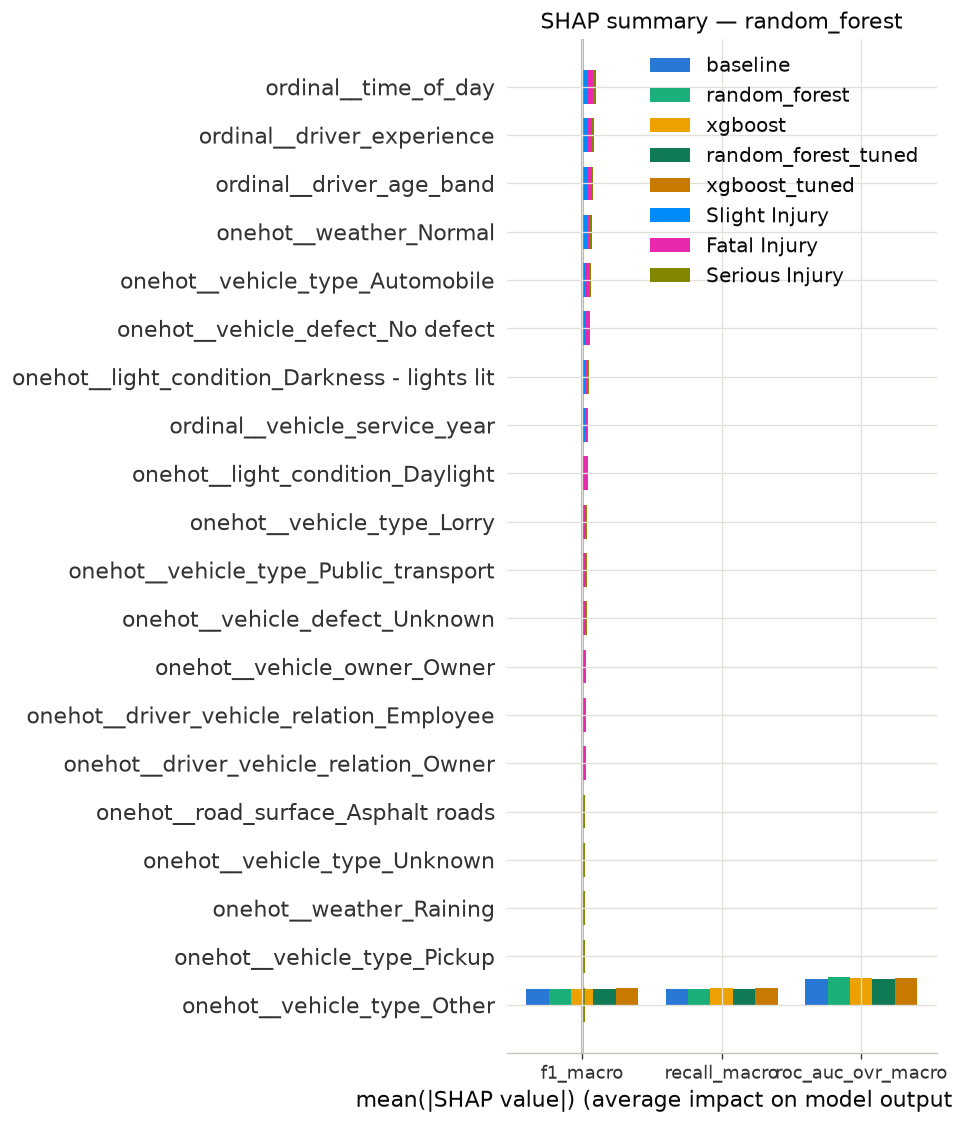

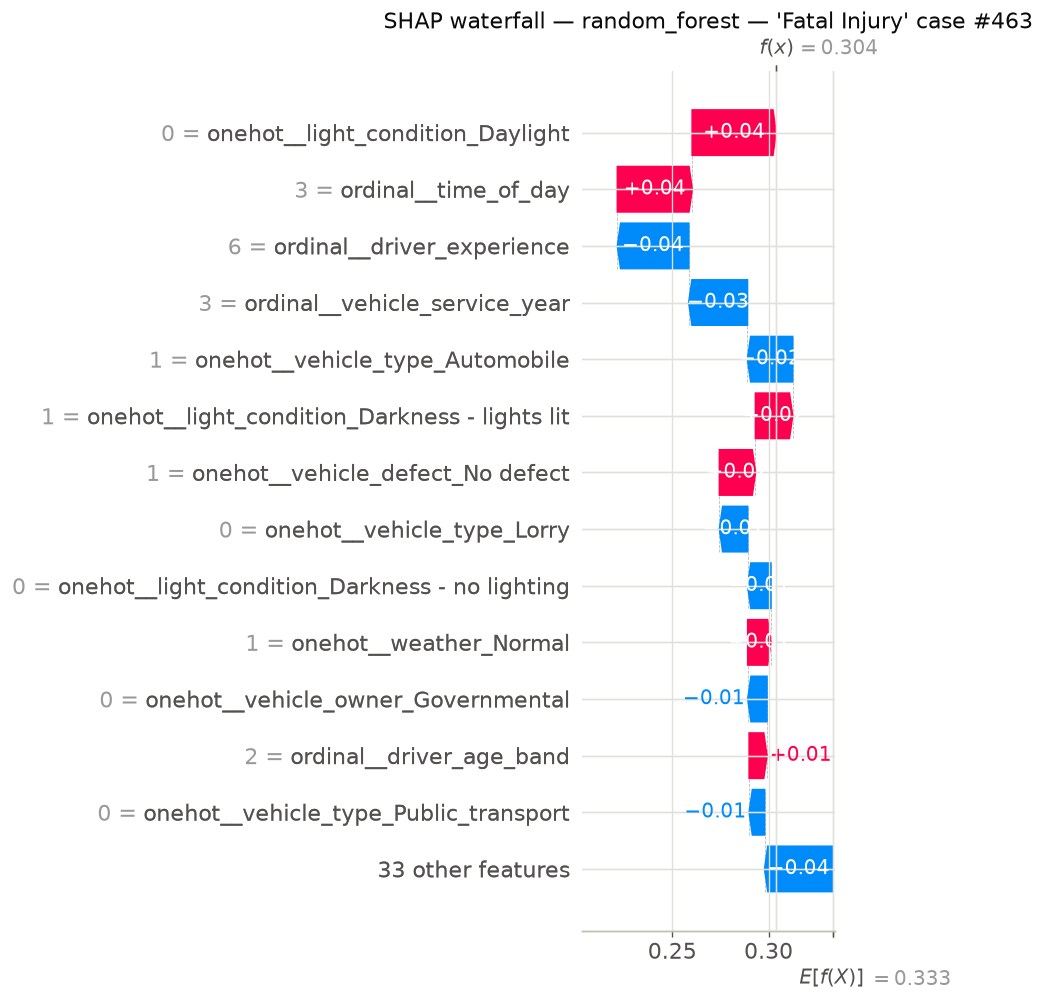

Top 10 features by mean |SHAP| (random_forest):


,feature,mean_abs_shap
0,ordinal__time_of_day,0.032430
1,ordinal__driver_experience,0.028062
2,ordinal__driver_age_band,0.025989
3,onehot__weather_Normal,0.023687
4,onehot__vehicle_type_Automobile,0.021565
5,onehot__vehicle_defect_No defect,0.018829
6,onehot__light_condition_Darkness - lights lit,0.015951
7,ordinal__vehicle_service_year,0.015264
8,onehot__light_condition_Daylight,0.014642
9,onehot__vehicle_type_Lorry,0.012755



=== SHAP: xgboost ===


[INFO] mbere-ml: shap[xgboost]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/xgboost


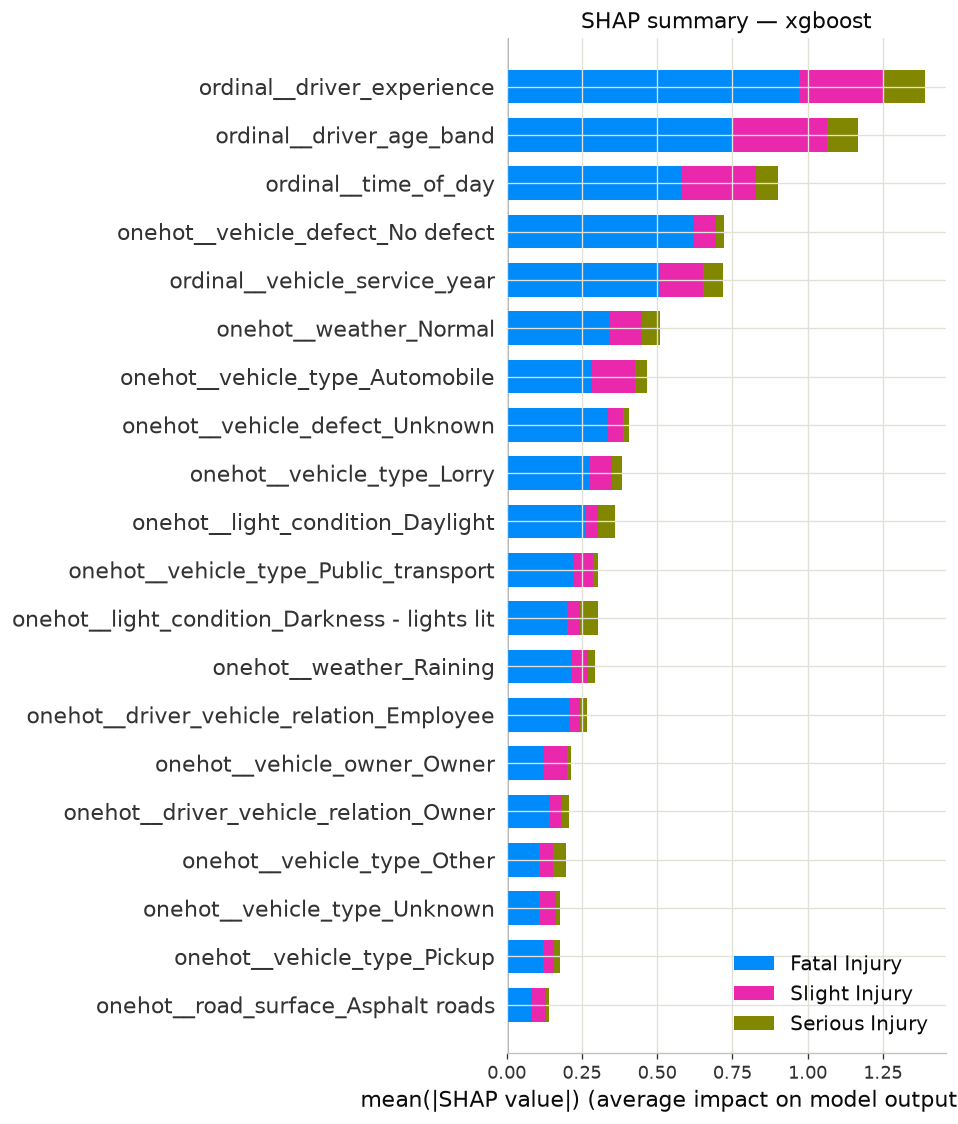

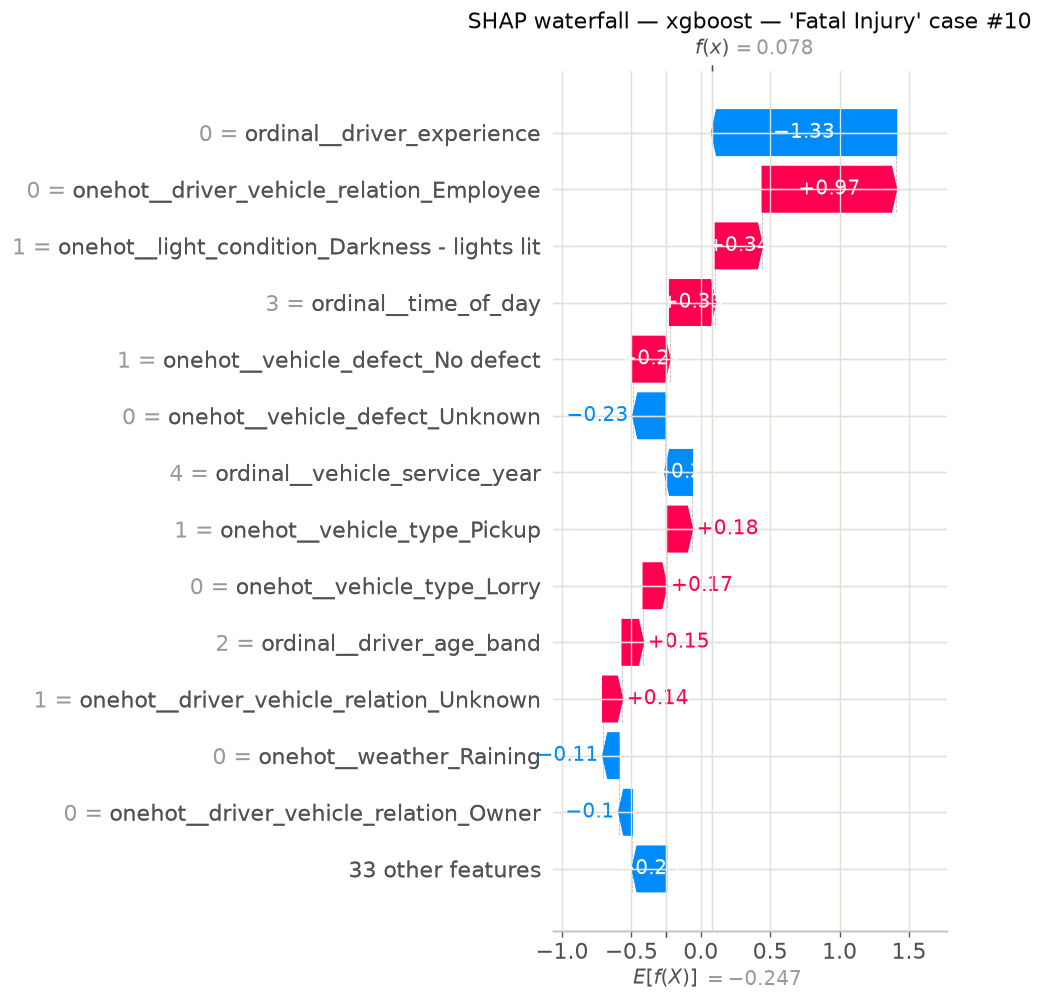

Top 10 features by mean |SHAP| (xgboost):


,feature,mean_abs_shap
0,ordinal__driver_experience,0.463613
1,ordinal__driver_age_band,0.388785
2,ordinal__time_of_day,0.300592
3,onehot__vehicle_defect_No defect,0.240364
4,ordinal__vehicle_service_year,0.239651
5,onehot__weather_Normal,0.169270
6,onehot__vehicle_type_Automobile,0.155202
7,onehot__vehicle_defect_Unknown,0.135338
8,onehot__vehicle_type_Lorry,0.127722
9,onehot__light_condition_Daylight,0.120392



=== SHAP: random_forest_tuned ===


[INFO] mbere-ml: shap[random_forest_tuned]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/random_forest_tuned


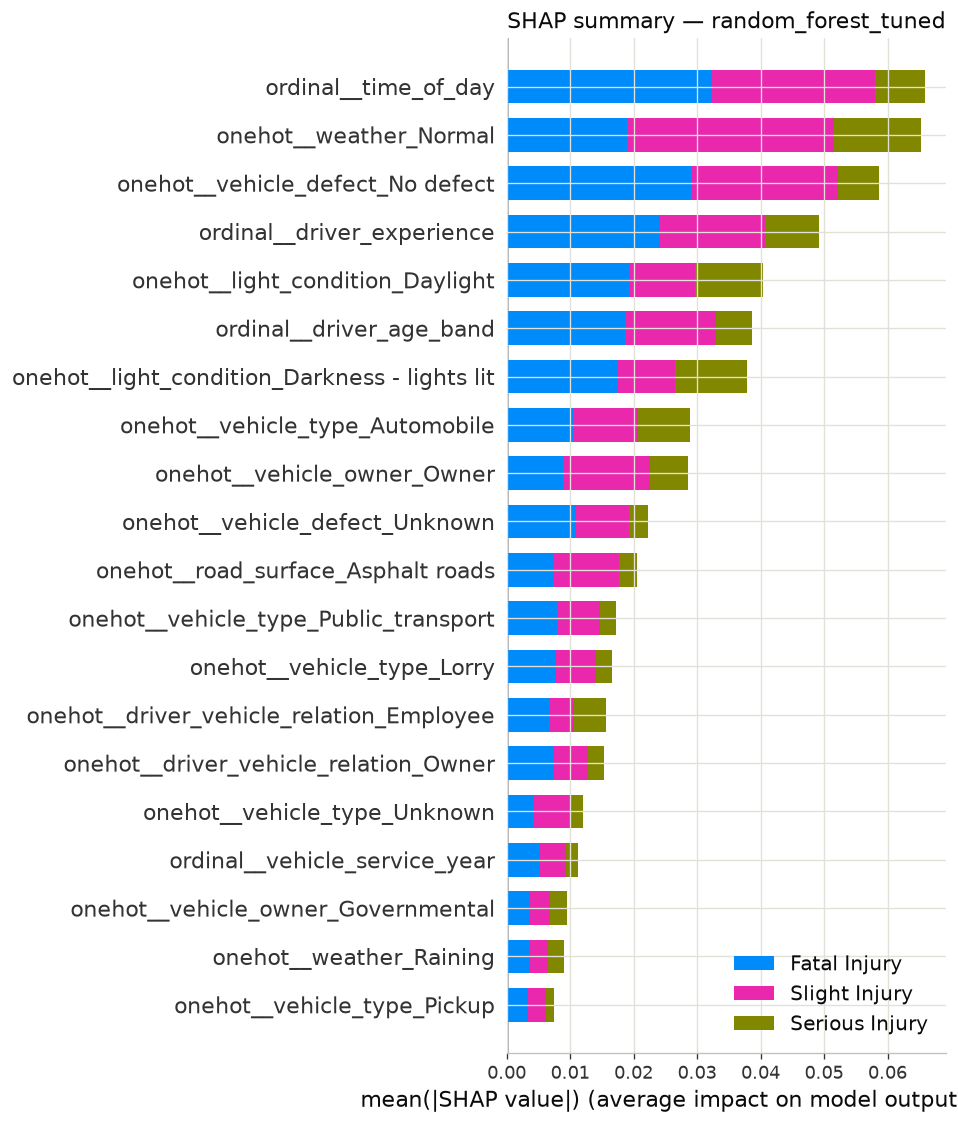

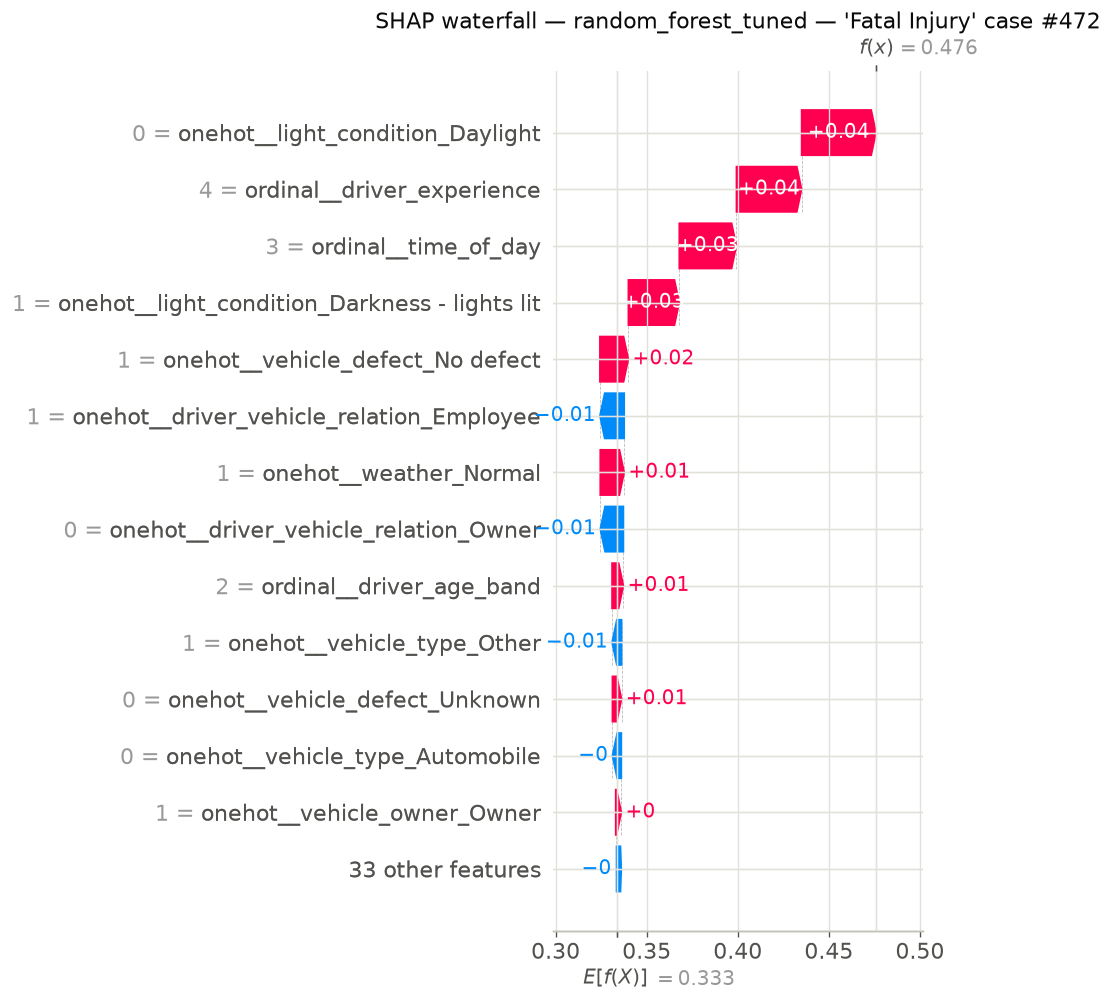

Top 10 features by mean |SHAP| (random_forest_tuned):


,feature,mean_abs_shap
0,ordinal__time_of_day,0.021983
1,onehot__weather_Normal,0.021736
2,onehot__vehicle_defect_No defect,0.019551
3,ordinal__driver_experience,0.016405
4,onehot__light_condition_Daylight,0.013470
5,ordinal__driver_age_band,0.012901
6,onehot__light_condition_Darkness - lights lit,0.012627
7,onehot__vehicle_type_Automobile,0.009645
8,onehot__vehicle_owner_Owner,0.009544
9,onehot__vehicle_defect_Unknown,0.007443



=== SHAP: xgboost_tuned ===


[INFO] mbere-ml: shap[xgboost_tuned]: wrote summary_plot.png, waterfall_plot.png, importance.csv -> /content/MBERE_ML/ml/artifacts/reports/xgboost_tuned


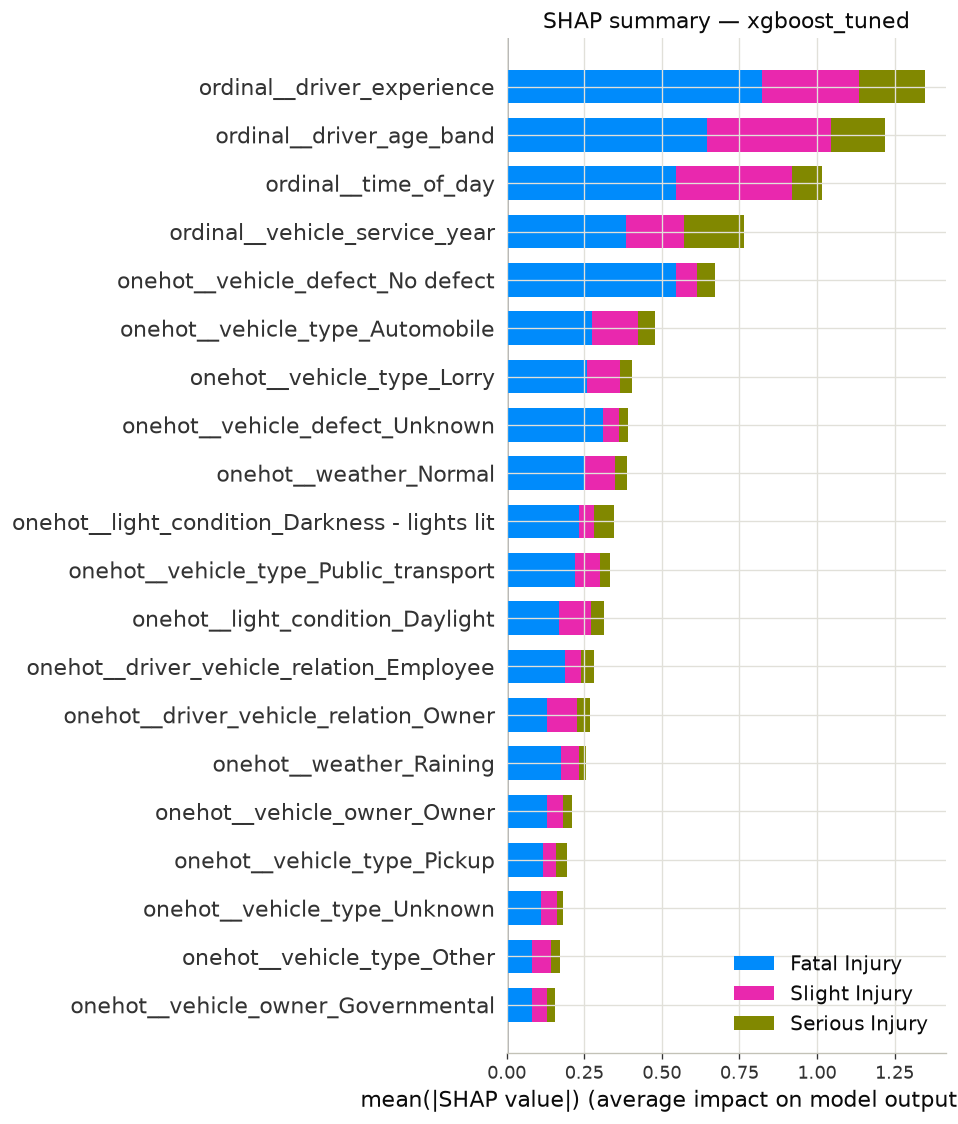

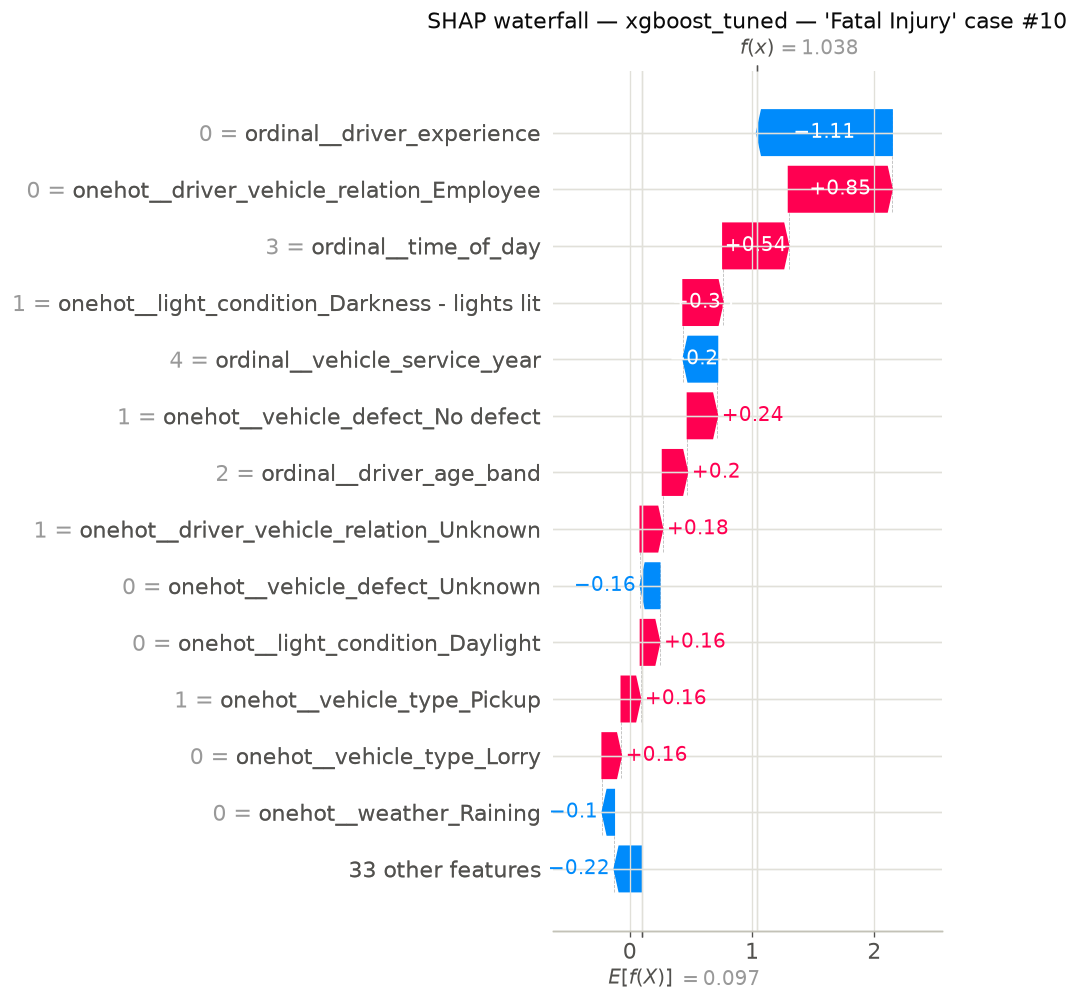

Top 10 features by mean |SHAP| (xgboost_tuned):


,feature,mean_abs_shap
0,ordinal__driver_experience,0.449649
1,ordinal__driver_age_band,0.405954
2,ordinal__time_of_day,0.338768
3,ordinal__vehicle_service_year,0.255449
4,onehot__vehicle_defect_No defect,0.224040
5,onehot__vehicle_type_Automobile,0.159207
6,onehot__vehicle_type_Lorry,0.135036
7,onehot__vehicle_defect_Unknown,0.130816
8,onehot__weather_Normal,0.128860
9,onehot__light_condition_Darkness - lights lit,0.115259


In [26]:
from ml.explainability.shap_analysis import analyze as shap_analyze

shap_summaries = {}
for model_name in ["random_forest", "xgboost", "random_forest_tuned", "xgboost_tuned"]:
    print(f"\n=== SHAP: {model_name} ===")
    summary = shap_analyze(config, model_name, sample_size=500)
    shap_summaries[model_name] = summary

    report_dir = config.paths.artifacts_dir / "reports" / model_name
    display(Image(filename=str(report_dir / "summary_plot.png")))
    display(Image(filename=str(report_dir / "waterfall_plot.png")))

    importance = pd.read_csv(report_dir / "importance.csv")
    print(f"Top 10 features by mean |SHAP| ({model_name}):")
    display(importance.head(10))

## 17. Saved artifacts & reproducibility

Every artifact below is versioned with its provenance (git commit, random_state, CV scheme) in its `.meta.json` sidecar, so any result in this notebook can be traced back to the exact code + data that produced it.


In [27]:
artifacts_dir = config.paths.artifacts_dir
for path in sorted(artifacts_dir.rglob("*")):
    if path.is_file():
        print(path.relative_to(artifacts_dir))

baseline.meta.json
baseline.pkl
encoders.joblib
feature_contract.json
random_forest.meta.json
random_forest.pkl
random_forest_tuned.meta.json
random_forest_tuned.pkl
reports/baseline/confusion_matrix.png
reports/baseline/metrics.json
reports/baseline/roc_curves.png
reports/random_forest/confusion_matrix.png
reports/random_forest/importance.csv
reports/random_forest/metrics.json
reports/random_forest/roc_curves.png
reports/random_forest/shap_summary.json
reports/random_forest/summary_plot.png
reports/random_forest/waterfall_plot.png
reports/random_forest_tuned/confusion_matrix.png
reports/random_forest_tuned/importance.csv
reports/random_forest_tuned/metrics.json
reports/random_forest_tuned/roc_curves.png
reports/random_forest_tuned/shap_summary.json
reports/random_forest_tuned/summary_plot.png
reports/random_forest_tuned/waterfall_plot.png
reports/xgboost/confusion_matrix.png
reports/xgboost/importance.csv
reports/xgboost/metrics.json
reports/xgboost/roc_curves.png
reports/xgboost/shap

In [28]:
# Provenance sidecar for the model Section 15 selected as best overall (could be
# baseline, an ordinary model, or a tuned one -- this reads whichever won).
with open(config.paths.artifacts_dir / f"{best_model}.meta.json") as fh:
    best_meta = json.load(fh)

print(f"{best_model}.meta.json (provenance):")
print(f"  git_commit  : {best_meta['git_commit']}")
print(f"  random_state: {best_meta['random_state']}")
print(f"  cv          : {best_meta['cv']}")
print(f"  dataset     : {best_meta['dataset']}")

xgboost_tuned.meta.json (provenance):
  git_commit  : 0ac2be6a4b4cf70e5a3f50ae0382deecb9e24d70
  random_state: 42
  cv          : {'scheme': 'StratifiedKFold', 'k_folds': 5, 'shuffle': True, 'random_state': 42}
  dataset     : {'name': 'addis', 'kind': 'multiclass', 'rows': 9852, 'target': 'Accident_severity', 'classes': ['Slight Injury', 'Serious Injury', 'Fatal Injury']}


In [29]:
# Reload the best model from disk and predict on a single held-out test row, end to end.
from ml.utils.artifacts import load_model

reloaded = load_model(config.paths.artifacts_dir / f"{best_model}.pkl")
sample_row = test_df[selected].iloc[[0]]
pred_idx = int(reloaded.predict(sample_row)[0])
pred_proba = reloaded.predict_proba(sample_row)[0]

print("Sample input features:")
display(sample_row)
print(f"Predicted severity: {config.target.classes[pred_idx]}")
print(f"Class probabilities: {dict(zip(config.target.classes, np.round(pred_proba, 4)))}")
print(f"Actual severity: {test_df[config.target.column].iloc[0]}")

Sample input features:


,driver_age_band,driver_experience,time_of_day,vehicle_service_year,vehicle_type,weather,road_surface,light_condition,driver_vehicle_relation,vehicle_owner,vehicle_defect
0,31-50,Above 10yr,Afternoon,5-10yrs,Public_transport,Normal,Asphalt roads,Daylight,Employee,Owner,No defect


Predicted severity: Serious Injury
Class probabilities: {'Slight Injury': np.float32(0.4677), 'Serious Injury': np.float32(0.5319), 'Fatal Injury': np.float32(0.0004)}
Actual severity: Slight Injury


## 18. Optional: synthetic (Rwandan) data sanity check

`ml.synthetic.generate` validates a **Fabricate-generated** synthetic Rwandan driver-risk CSV against the real feature vocabulary (`feature_contract.json`) and runs a contextual monotonicity check (mean P(Fatal) / P(Serious) should increase with the synthetic dataset's own severity label).

> **This is context/robustness validation only** — it is never merged into `metrics.json` and never used as performance ground truth; the Addis held-out test set (Sections 14-15) remains the sole source of performance metrics.

This section needs an external CSV that is **not** part of the repository (it's generator-tool output, not tracked in git). Upload one to `data/external/<name>.csv` in the Colab file browser to run it; otherwise this cell skips gracefully.


In [30]:
from pathlib import Path

external_dir = Path("data/external")
synthetic_csvs = sorted(external_dir.glob("*.csv")) if external_dir.is_dir() else []

if not synthetic_csvs:
    print("No synthetic CSV found under data/external/ -- skipping.")
    print("To run this section: upload a Fabricate-generated CSV "
          "(must include a 'synthetic_severity_label' column) to data/external/, then re-run this cell.")
else:
    from ml.synthetic.generate import load_and_validate, sanity_check

    synthetic_path = synthetic_csvs[0]
    print(f"Found {synthetic_path} -- validating against the feature contract...")

    synthetic_df = load_and_validate(synthetic_path, config.paths.artifacts_dir / "feature_contract.json")
    print(f"Validated {len(synthetic_df)} synthetic rows.")

    result = sanity_check(
        synthetic_df,
        model_path=config.paths.artifacts_dir / f"{best_model}.pkl",
        encoder_path=config.paths.artifacts_dir / "encoders.joblib",
        contract_path=config.paths.artifacts_dir / "feature_contract.json",
    )
    print(json.dumps(result, indent=2))

No synthetic CSV found under data/external/ -- skipping.
To run this section: upload a Fabricate-generated CSV (must include a 'synthetic_severity_label' column) to data/external/, then re-run this cell.


## 19. Download artifacts from Colab

Zips `ml/artifacts/` (models, metadata, reports, SHAP plots) and `data/processed/` (encoded train/test sets) for download. This only works when running on Colab.


In [31]:
import shutil

shutil.make_archive("/content/ml_artifacts", "zip", "ml/artifacts")
shutil.make_archive("/content/processed_data", "zip", "data/processed")

try:
    from google.colab import files
    files.download("/content/ml_artifacts.zip")
    files.download("/content/processed_data.zip")
except ImportError:
    print("Not running on Colab -- archives written to /content/*.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion

- **Data**: Addis Ababa RTA data, cleaned leakage-safe and deterministically, with 11-13 interpretable engineered features selected by train-only mutual information.
- **Models**: a transparent rule-based baseline, plus Random Forest and XGBoost classifiers each trained in both an ordinary (Section 12.2/12.3) and hyperparameter-tuned (Section 12.4) configuration — five models total, all trained through the same leak-free `StratifiedKFold` + in-pipeline resampling harness.
- **Evaluation**: out-of-fold CV metrics and held-out test metrics agree closely (see Sections 13 & 15), with macro F1 / recall / ROC-AUC as headline metrics given class imbalance. Section 15 selects the single best-performing model of all five by test `f1_macro`.
- **Explainability**: SHAP summary and waterfall plots show which engineered features (e.g. driver age band, experience, night + poor lighting, vehicle type) drive severity predictions for all four tree models (ordinary and tuned).
- **Reproducibility**: every saved model carries a metadata sidecar with its git commit, random seed, and CV scheme, so any number in this notebook can be traced back to exact code + data.

**Next steps:** wire the winning model (Section 15) into the backend inference service via `feature_contract.json`; extend `ml/configs/` with additional dataset configs as more labeled data becomes available; if the Fatal class remains the hardest to predict, consider collecting more Fatal-class data or a cost-sensitive threshold adjustment rather than further resampling tweaks.
